In [36]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle 
import scipy
import time as tim
import os
from scipy.io import loadmat

#from neuromancer.psl import plot
#from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.slim import slim
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler
torch.manual_seed(0)

In [37]:
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
os.chdir(SEM2025_DIR)

print("SEM2025_DIR =", SEM2025_DIR)
print("cwd =", os.getcwd())

train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data_mat = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

SEM2025_DIR = C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026
cwd = C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026


Dataset split a základné parametre

In [38]:
nsteps = 50
bs = 100

train_sim = {
    "Y": train_data["Ytrain"],
    "U": train_data["Utrain"],
}

test_sim = {
    "Y": test_data_mat["Ytest"],
    "U": test_data_mat["Utest"],
}

nx = train_sim["Y"].shape[1]
ny = train_sim["Y"].shape[1]
nu = train_sim["U"].shape[1]

nx_koopman = 80
layers = [60, 60, 60]

print("nx =", nx)
print("ny =", ny)
print("nu =", nu)
print("nx_koopman =", nx_koopman)

nx = 1
ny = 1
nu = 1
nx_koopman = 80


Funkcia na prípravu loaderov

In [39]:
def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
    dev_sim = train_sim

    # TRAIN
    nsim = train_sim["Y"].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    trainX = scaler.transform(train_sim["Y"][:length]).reshape(nbatch, nsteps, nx)
    trainU = scalerU.transform(train_sim["U"][:length]).reshape(nbatch, nsteps, nu)

    train_dataset = DictDataset(
        {
            "Y": torch.tensor(trainX, dtype=torch.float32),
            "Y0": torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
            "U": torch.tensor(trainU, dtype=torch.float32),
        },
        name="train",
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=bs,
        collate_fn=train_dataset.collate_fn,
        shuffle=True,
    )

    # DEV
    nsim = dev_sim["Y"].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    devX = scaler.transform(dev_sim["Y"][:length]).reshape(nbatch, nsteps, nx)
    devU = scalerU.transform(dev_sim["U"][:length]).reshape(nbatch, nsteps, nu)

    dev_dataset = DictDataset(
        {
            "Y": torch.tensor(devX, dtype=torch.float32),
            "Y0": torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
            "U": torch.tensor(devU, dtype=torch.float32),
        },
        name="dev",
    )

    dev_loader = DataLoader(
        dev_dataset,
        batch_size=bs,
        collate_fn=dev_dataset.collate_fn,
        shuffle=False,
    )

    # TEST
    nsim = test_sim["Y"].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    testX = scaler.transform(test_sim["Y"][:length]).reshape(1, nbatch * nsteps, nx)
    testU = scalerU.transform(test_sim["U"][:length]).reshape(1, nbatch * nsteps, nu)

    test_dataset = {
        "Y": torch.tensor(testX, dtype=torch.float32),
        "Y0": torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
        "U": torch.tensor(testU, dtype=torch.float32),
    }

    return train_loader, dev_loader, test_dataset

Vytvorenie loaderov a rýchly plot dát

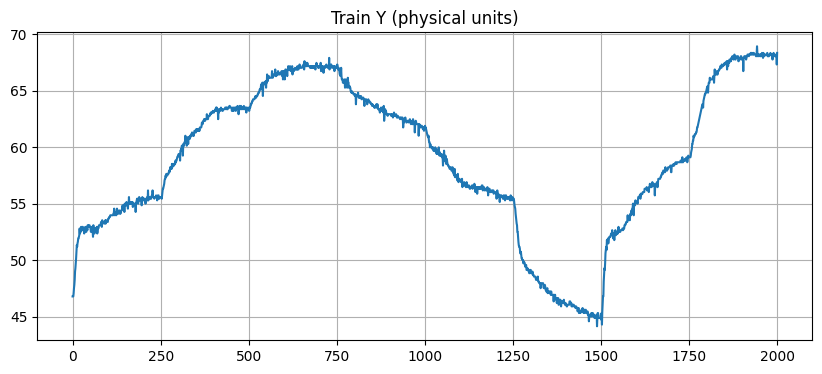

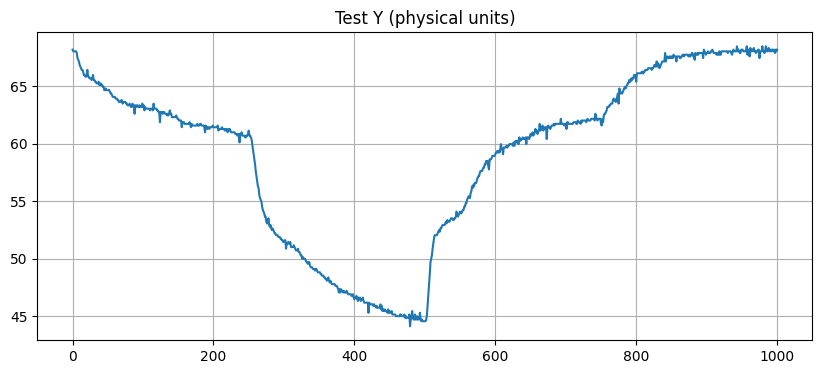

In [40]:
train_loader, dev_loader, test_data = get_data(
    train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU
)

plt.figure(figsize=(10, 4))
plt.plot(train_sim["Y"])
plt.title("Train Y (physical units)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(test_sim["Y"])
plt.title("Test Y (physical units)")
plt.grid(True)
plt.show()

Definícia Deep Koopman modelu

In [41]:
# Encoder f_y
f_y = blocks.MLP(
    ny,
    nx_koopman,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers,
)

encode_Y0 = Node(f_y, ["Y0"], ["x"], name="encoder_Y0")
encode_Y = Node(f_y, ["Y"], ["x_latent"], name="encoder_Y")

# Input encoder f_u
f_u = torch.nn.Linear(nu, nx_koopman, bias=False)
encode_U = Node(f_u, ["U"], ["u_latent"], name="encoder_U")

# Decoder f_y_inv
f_y_inv = blocks.MLP(
    nx_koopman,
    ny,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ELU,
    hsizes=layers[::-1],
)

decode_y = Node(f_y_inv, ["x"], ["yhat"], name="decoder_y")

Koopman operator

In [42]:
stable = False #trenovanie

if stable:
    K = slim.linear.SVDLinear(
        nx_koopman,
        nx_koopman,
        sigma_min=0.001,
        sigma_max=0.999,
        bias=False,
    )
    K_reg_error = variable(K.reg_error())
    K_reg_loss = 1.0 * (K_reg_error == 0.0)
    K_reg_loss.name = "SVD_loss"
else:
    K = torch.nn.Linear(nx_koopman, nx_koopman, bias=False)

Dynamika v latentnom priestore

In [43]:
class Koopman_control(nn.Module):
    """
    x_{k+1} = K x_k + u_latent
    """

    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, u):
        return self.K(x) + u


Koopman = Node(Koopman_control(K), ["x", "u_latent"], ["x"], name="K")
dynamics_model = System([Koopman], name="Koopman", nsteps=nsteps)

nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

Loss funkcia

In [44]:
Y = variable("Y")
yhat = variable("yhat")
x_latent = variable("x_latent")
u_latent = variable("u_latent")
x = variable("x")

xu_latent = x_latent + u_latent

# prediction loss
y_loss = ((yhat[:, 1:-1, :] - Y[:, 1:, :]) ** 2).minimize(weight=10.0, name="y_loss")

# one-step ahead loss
onestep_loss = ((yhat[:, 1, :] - Y[:, 1, :]) ** 2).minimize(weight=1.0, name="onestep_loss")

# autoencoder reconstruction loss
reconstruction_loss = ((yhat[:, 0, :] - Y[:, 0, :]) ** 2).minimize(weight=20.0, name="reconstruction_loss")

# latent consistency loss
x_loss = ((x[:, 1:-1, :] - xu_latent[:, 1:, :]) ** 2).minimize(weight=1.0, name="x_loss")

objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

if stable:
    objectives.append(K_reg_loss)

loss = PenaltyLoss(objectives, constraints=[])
problem = Problem(nodes, loss)

print(problem.input_keys)
print(problem.output_keys)

['Y0', 'u_latent', 'x_latent', 'x', 'U', 'yhat', 'Y']
['u_latent', 'loss', 'x_latent', 'penalty_loss', 'x', 'objective_loss', 'yhat', 'C_ineq_violations', 'C_violations', 'C_eq_values', 'C_values', 'C_ineq_values', 'C_eq_violations']


In [45]:
batch0 = next(iter(train_loader))
out0 = problem(batch0)

print("Forward pass OK")
for k, v in out0.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape))

Forward pass OK
train_Y (40, 50, 1)
train_Y0 (40, 1, 1)
train_U (40, 50, 1)
train_x (40, 51, 80)
train_x_latent (40, 50, 80)
train_u_latent (40, 50, 80)
train_yhat (40, 51, 1)
train_2353137574544 (40, 49, 1)
train_2353137571600 (40, 49, 1)
train_2353126160464 (40, 49, 1)
train_2353137576976 (40, 49, 1)
train_2353114814288 (40, 49, 80)
train_2353122332176 (40, 50, 80)
train_2353114815504 (40, 49, 80)
train_2353118200016 (40, 49, 80)
train_2353122685264 (40, 49, 80)
train_2353118212944 (40, 1)
train_2353126095696 (40, 1)
train_2353122467792 (40, 1)
train_2353114777552 (40, 1)
train_2353130409744 (40, 1)
train_2353130416912 (40, 1)
train_2353136799632 (40, 1)
train_2353114809296 (40, 1)
train_2353137576976_<built-in method mean of type object at 0x00007FFEA55FB860> ()
train_2353122685264_<built-in method mean of type object at 0x00007FFEA55FB860> ()
train_2353114777552_<built-in method mean of type object at 0x00007FFEA55FB860> ()
train_2353114809296_<built-in method mean of type object a

Tréning

In [46]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    patience=300,
    warmup=100,
    epochs=5000,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)

start = tim.time()
best_model = trainer.train()
problem.load_state_dict(best_model)
end = tim.time()

print(f"Elapsed time train: {end - start:.2f} sec")

epoch: 0  train_loss: 28.86945915222168
epoch: 1  train_loss: 26.429122924804688
epoch: 2  train_loss: 24.436939239501953
epoch: 3  train_loss: 22.742630004882812
epoch: 4  train_loss: 21.288171768188477
epoch: 5  train_loss: 20.143070220947266
epoch: 6  train_loss: 19.441173553466797
epoch: 7  train_loss: 19.10319709777832
epoch: 8  train_loss: 18.67094612121582
epoch: 9  train_loss: 17.875595092773438
epoch: 10  train_loss: 16.750349044799805
epoch: 11  train_loss: 15.411214828491211
epoch: 12  train_loss: 13.958471298217773
epoch: 13  train_loss: 12.426229476928711
epoch: 14  train_loss: 10.80152702331543
epoch: 15  train_loss: 9.077680587768555
epoch: 16  train_loss: 7.303460121154785
epoch: 17  train_loss: 5.589838981628418
epoch: 18  train_loss: 4.131353378295898
epoch: 19  train_loss: 3.1869587898254395
epoch: 20  train_loss: 2.9754040241241455
epoch: 21  train_loss: 3.4476120471954346
epoch: 22  train_loss: 4.157522201538086
epoch: 23  train_loss: 4.597430229187012
epoch: 24  t

Uloženie modelu

In [47]:
timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(SEM2025_DIR, "data")
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"model_{timestamp_str}.pth")
torch.save(best_model, save_path)

print("Saved to:", save_path)

Saved to: C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\data\model_20260307_120420.pth


Kontrola načítania uloženého modelu

In [48]:
test_outputs_mem = problem.step(test_data)
pred_mem = test_outputs_mem["yhat"][:, 1:-1, :].detach().cpu().numpy()

# rebuild fresh problem with same architecture
problem_fresh = Problem(nodes, loss)
problem_fresh.load_state_dict(torch.load(save_path, map_location="cpu"), strict=False)

test_outputs_file = problem_fresh.step(test_data)
pred_file = test_outputs_file["yhat"][:, 1:-1, :].detach().cpu().numpy()

print("max abs diff:", np.max(np.abs(pred_mem - pred_file)))

max abs diff: 0.0


Helper funkcie pre encoder/decoder

In [49]:
def get_x_scaled(y_scaled):
    """
    y_scaled: np.array shape (1, ny)
    """
    x_dict = problem.nodes[0]({"Y0": torch.from_numpy(y_scaled).float()})
    return x_dict["x"].detach().cpu().numpy().reshape(-1, 1)


def get_y_scaled(x_latent):
    """
    x_latent: np.array shape (nx_koopman, 1)
    """
    y_dict = problem.nodes[4]({"x": torch.from_numpy(x_latent.T).float()})
    return y_dict["yhat"][0].detach().cpu().numpy().reshape(-1, 1)


def get_x_phys(y_phys):
    """
    y_phys: float
    """
    y_scaled = scaler.transform(np.array([[y_phys]]))
    return get_x_scaled(y_scaled)


def get_y_phys(x_latent):
    """
    returns np.array shape (1, ny) in physical units
    """
    y_scaled = get_y_scaled(x_latent).T
    return scaler.inverse_transform(y_scaled)

Test rollout current modelu

In [50]:
problem.nodes[3].nsteps = test_data["U"].shape[1]

start = tim.time()
test_outputs = problem.step(test_data)
end = tim.time()

print(f"Elapsed time test: {end - start:.2f} sec")

pred_traj = test_outputs["yhat"][:, 1:-1, :].detach().cpu().numpy().reshape(-1, nx).T
true_traj = test_data["Y"][:, 1:pred_traj.shape[1] + 1, :].detach().cpu().numpy().reshape(-1, nx).T
input_traj = test_data["U"].detach().cpu().numpy().reshape(-1, nu).T
pred_x = test_outputs["x"][:, 1:-1, :].detach().cpu().numpy().reshape(-1, nx_koopman).T

print("pred_traj shape:", pred_traj.shape)
print("true_traj shape:", true_traj.shape)
print("input_traj shape:", input_traj.shape)
print("pred_x shape:", pred_x.shape)

mse_scaled = np.mean((pred_traj - true_traj) ** 2)
print("Prediction MSE (scaled):", mse_scaled)

Elapsed time test: 0.26 sec
pred_traj shape: (1, 999)
true_traj shape: (1, 999)
input_traj shape: (1, 1000)
pred_x shape: (80, 999)
Prediction MSE (scaled): 0.045837104


Plot test trajektórií

In [51]:
# scaled -> physical units

# trajectories are currently shape (nx, N) and (nu, N)
# scaler/scalerU expect shape (N, n_features), so transpose first

pred_traj_phys = scaler.inverse_transform(pred_traj.T).T
true_traj_phys = scaler.inverse_transform(true_traj.T).T
input_traj_phys = scalerU.inverse_transform(input_traj.T).T

print("pred_traj_phys shape:", pred_traj_phys.shape)
print("true_traj_phys shape:", true_traj_phys.shape)
print("input_traj_phys shape:", input_traj_phys.shape)

pred_traj_phys shape: (1, 999)
true_traj_phys shape: (1, 999)
input_traj_phys shape: (1, 1000)


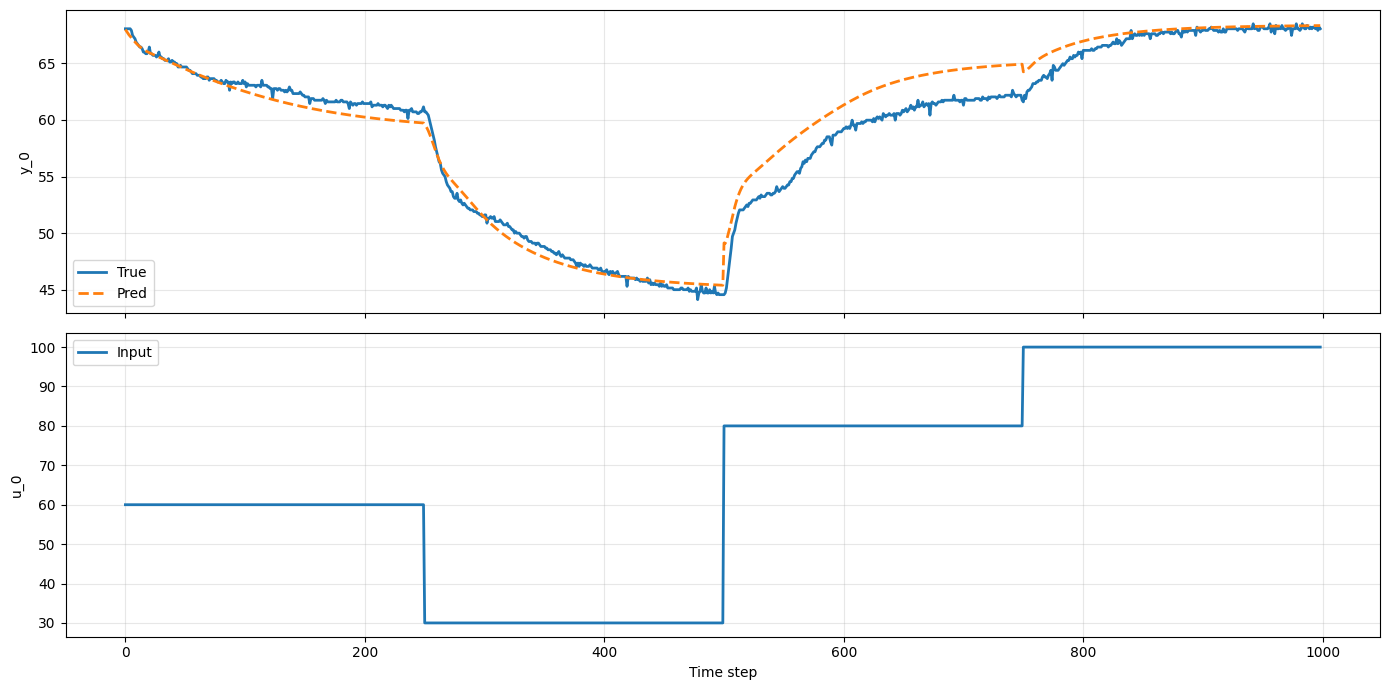

In [52]:
figsize = 16
part = min(1000, pred_traj_phys.shape[1])

fig, ax = plt.subplots(nx + nu, 1, figsize=(14, 7), sharex=True)

x_labels = [f"y_{k}" for k in range(len(true_traj_phys))]
for row, (t1, t2, label) in enumerate(zip(true_traj_phys, pred_traj_phys, x_labels)):
    ax[row].plot(t1[:part], linewidth=2, label="True")
    ax[row].plot(t2[:part], "--", linewidth=2, label="Pred")
    ax[row].set_ylabel(label)
    ax[row].grid(True, alpha=0.3)
    ax[row].legend()

u_labels = [f"u_{k}" for k in range(len(input_traj_phys))]
for row, (u, label) in enumerate(zip(input_traj_phys, u_labels)):
    ax[row + nx].plot(u[:part], linewidth=2, label="Input")
    ax[row + nx].set_ylabel(label)
    ax[row + nx].grid(True, alpha=0.3)
    ax[row + nx].legend()

ax[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

Extrakcia lineárneho Koopman modelu

In [53]:
if stable:
    A_koop = K.effective_W().detach().cpu().numpy()
else:
    A_koop = K.weight.detach().cpu().numpy()

B_koop = f_u.weight.detach().cpu().numpy()

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("||B_koop|| =", np.linalg.norm(B_koop))
print("B_koop min/max =", B_koop.min(), B_koop.max())

is_ctrl, rank, Ctrb = controllability_test(A_koop, B_koop)
print("controllability rank:", rank)

A_koop shape: (80, 80)
B_koop shape: (80, 1)
||B_koop|| = 5.079272
B_koop min/max = -0.9595012 0.9669262
controllability rank: 18


Controllability test

In [66]:
print("A_koop dtype:", A_koop.dtype)
print("B_koop dtype:", B_koop.dtype)
print("A_koop first row:", A_koop[0, :5])
print("B_koop first 10:", B_koop[:10, 0])
print("max |eig(A_koop)| =", np.max(np.abs(np.linalg.eigvals(A_koop))))
print("rank(B_koop) =", np.linalg.matrix_rank(B_koop))


A_koop dtype: float32
B_koop dtype: float32
A_koop first row: [ 0.06462854  0.02251293  0.07063577 -0.0349674  -0.02485609]
B_koop first 10: [ 0.81706595  0.8922582   0.7069427  -0.8785153  -0.5520711   0.22748075
 -0.8879866  -0.03145022  0.3281562  -0.29523852]
max |eig(A_koop)| = 0.98811054
rank(B_koop) = 1


In [67]:
Ctrb = B_koop
for i in range(1, A_koop.shape[0]):
    Ctrb = np.hstack((Ctrb, np.linalg.matrix_power(A_koop, i) @ B_koop))

print("Ctrb shape:", Ctrb.shape)
print("Ctrb norm:", np.linalg.norm(Ctrb))
print("Ctrb rank:", np.linalg.matrix_rank(Ctrb))

Ctrb shape: (80, 80)
Ctrb norm: 5.1727204
Ctrb rank: 18


In [54]:
def controllability_test(A, B):
    n = A.shape[0]
    controllability_matrix = B

    for i in range(1, n):
        controllability_matrix = np.hstack(
            (controllability_matrix, np.linalg.matrix_power(A, i) @ B)
        )

    rank = np.linalg.matrix_rank(controllability_matrix)
    return rank == n, rank, controllability_matrix


is_controllable, rank, C_matrix = controllability_test(A_koop, B_koop)
print(f"System is controllable: {is_controllable}")
print(f"Rank: {rank}/{A_koop.shape[0]}")

System is controllable: False
Rank: 18/80


Koopman eigenvalues

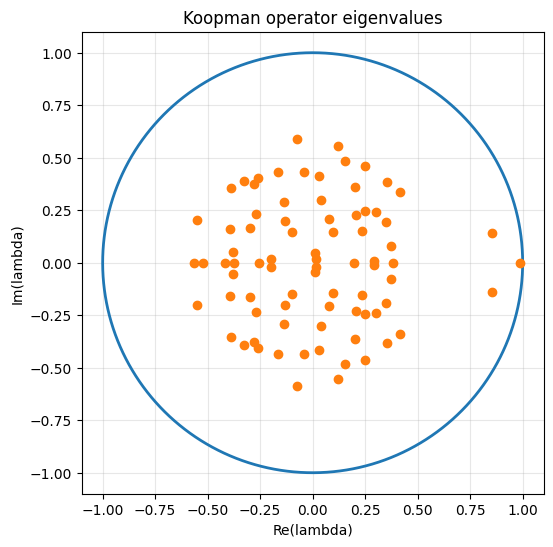

In [55]:
if stable:
    eig, eig_vec = torch.linalg.eig(K.effective_W())
else:
    eig, eig_vec = torch.linalg.eig(K.weight)

eReal = eig.real.detach().cpu().numpy()
eImag = eig.imag.detach().cpu().numpy()

t = np.linspace(0.0, 2 * np.pi, 1000)
x_circ = np.cos(t)
y_circ = np.sin(t)

fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.plot(x_circ, y_circ, linewidth=2)
ax1.plot(eReal, eImag, "o")
ax1.set_aspect("equal", "box")
ax1.set_xlabel("Re(lambda)")
ax1.set_ylabel("Im(lambda)")
ax1.set_title("Koopman operator eigenvalues")
ax1.grid(True, alpha=0.3)
plt.show()

Encoder-decoder consistency check

In [56]:
x0_check = get_x_scaled(np.array([[1.0]]))
x_tmp = x0_check.copy()

for i in range(100):
    y_tmp = get_y_scaled(x_tmp)
    x_tmp = get_x_scaled(y_tmp.T)

print("Consistency error:", np.sum((x0_check - x_tmp) ** 2))

Consistency error: 0.00048947096


. Vizualizácia latent trajectory vs re-encoded trajectory

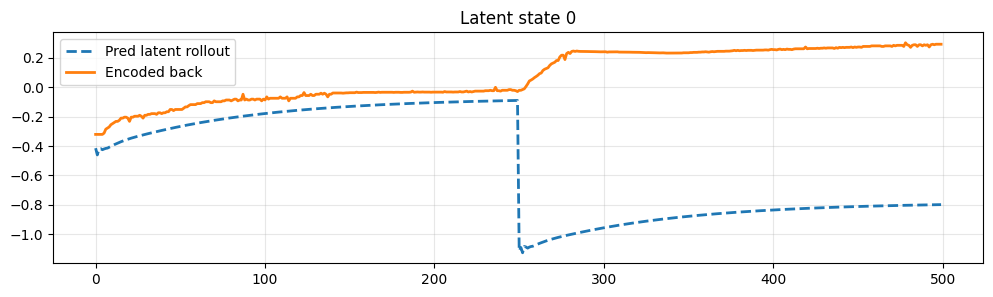

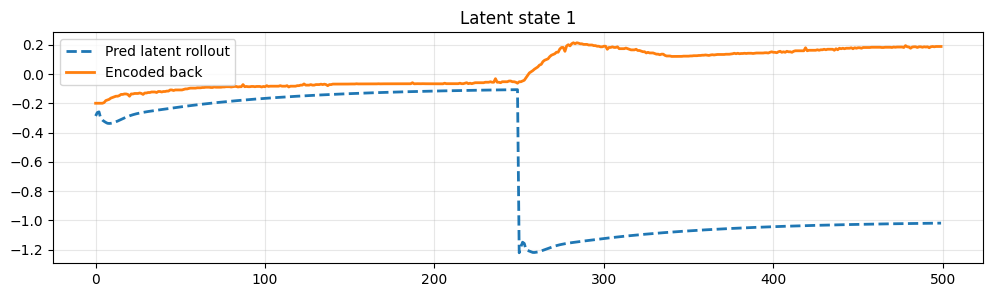

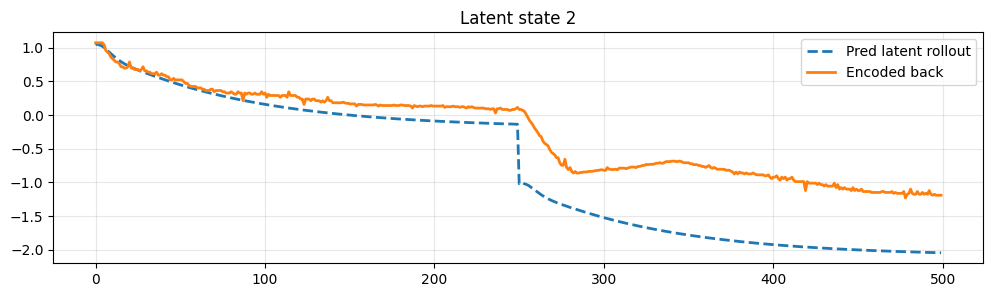

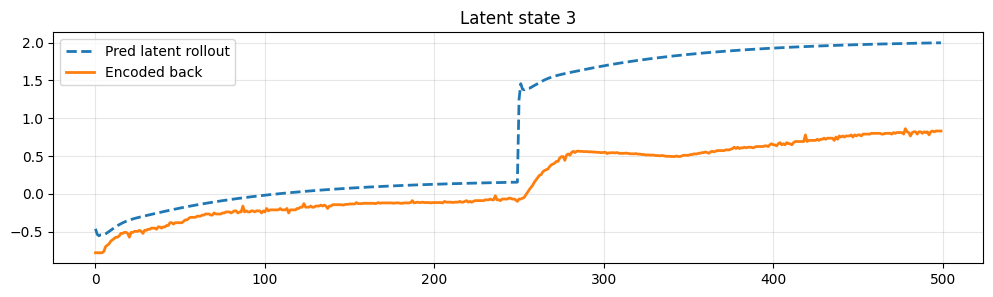

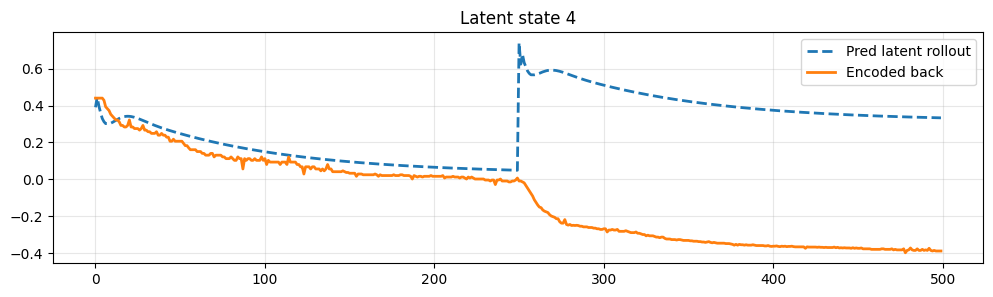

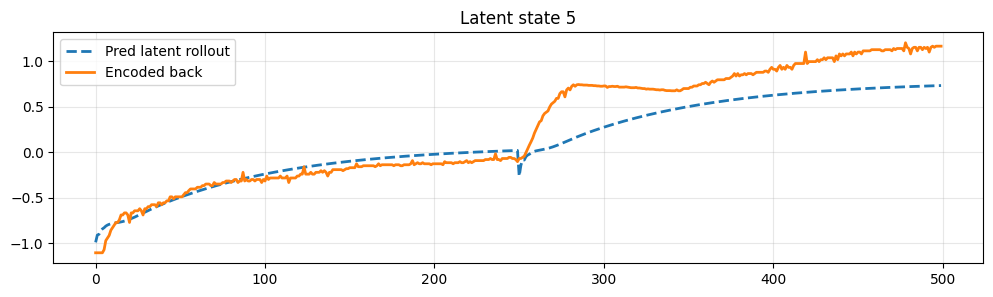

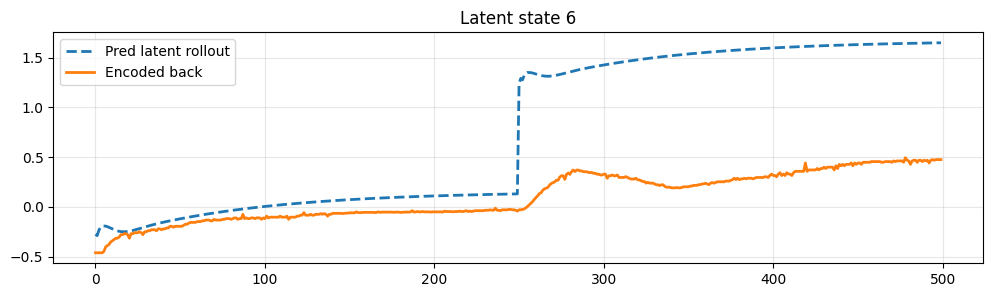

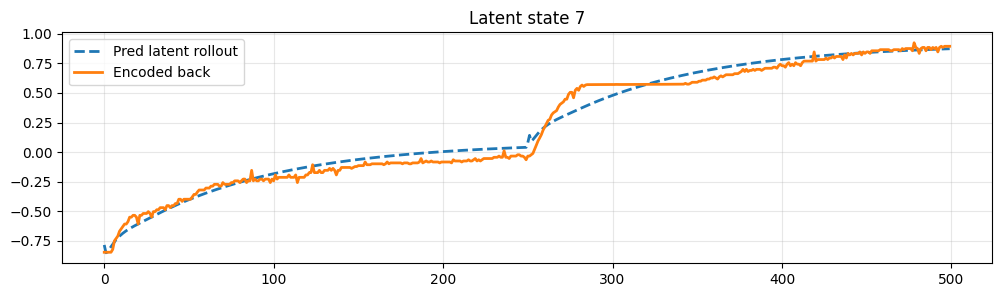

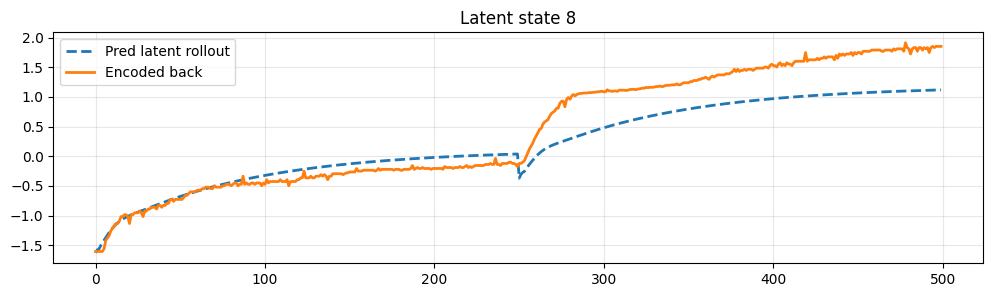

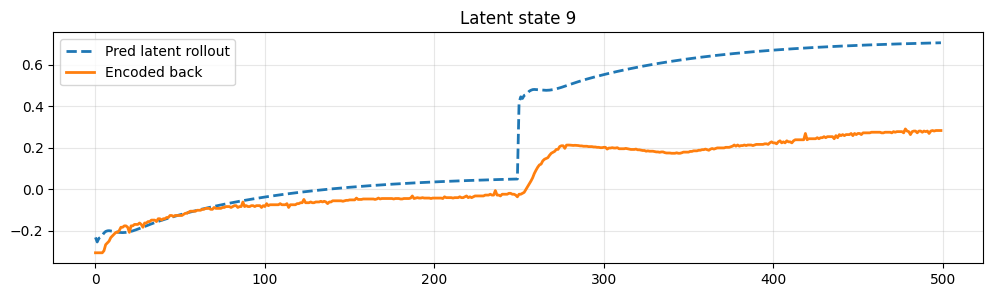

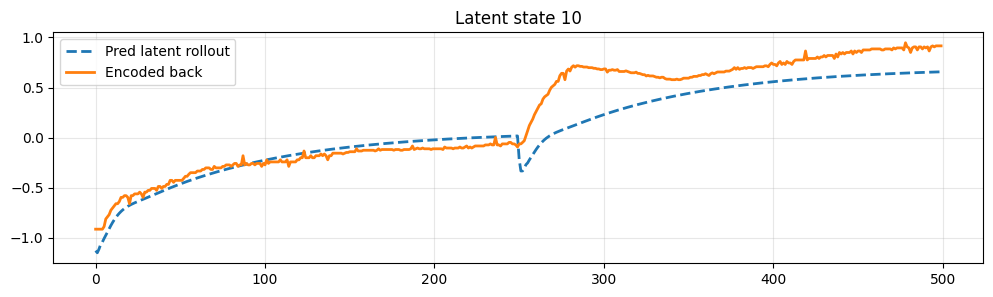

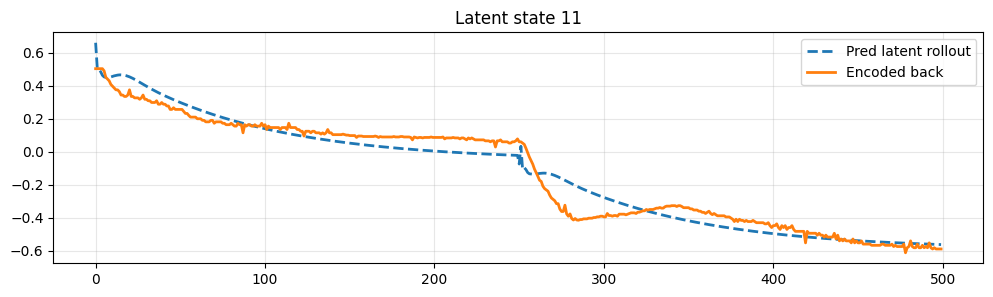

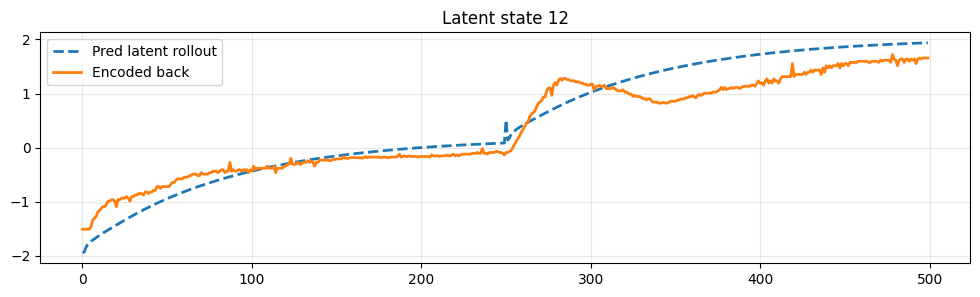

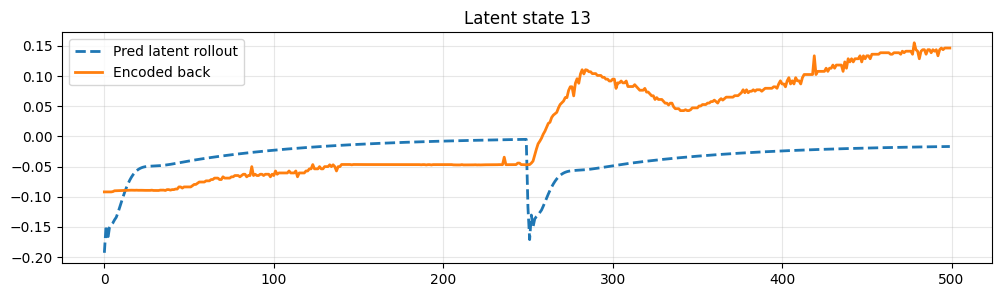

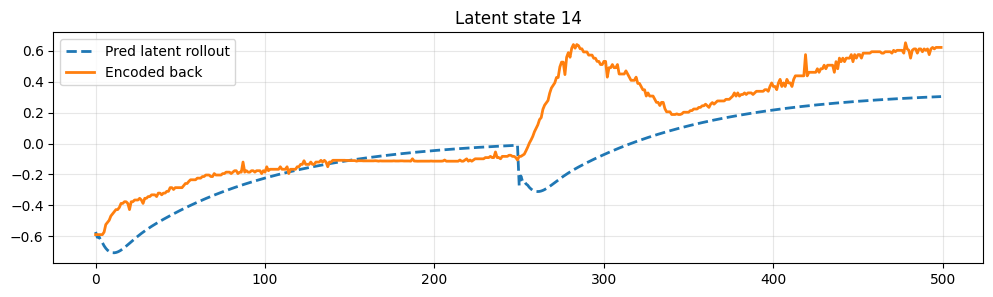

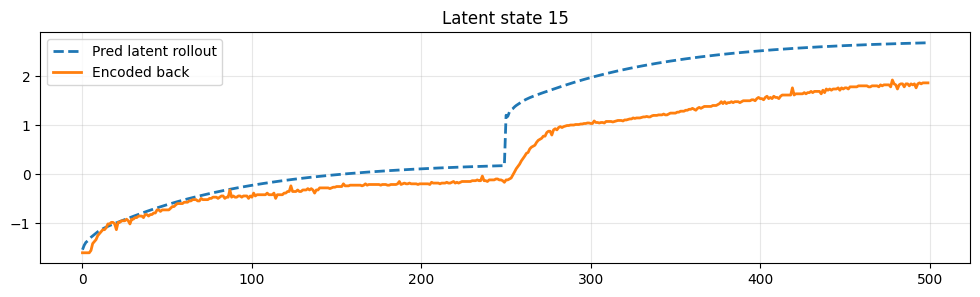

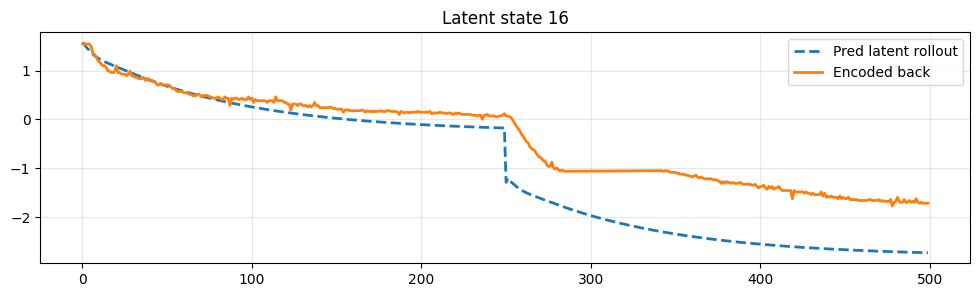

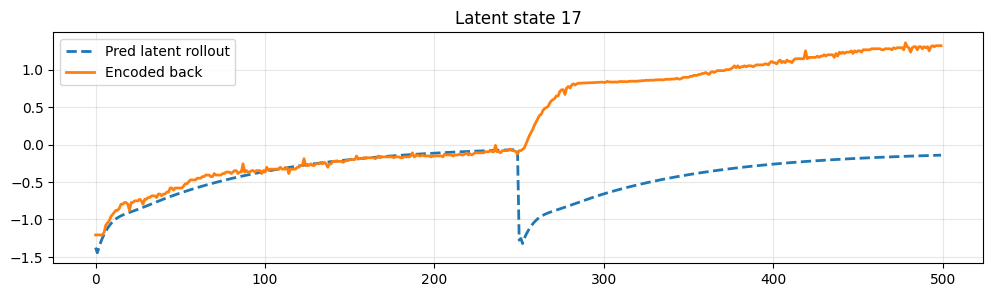

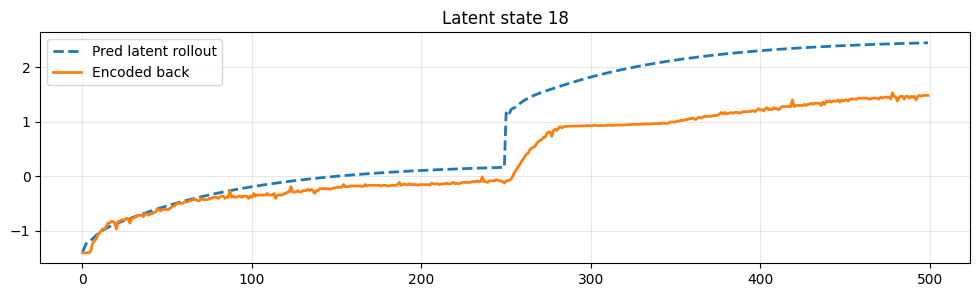

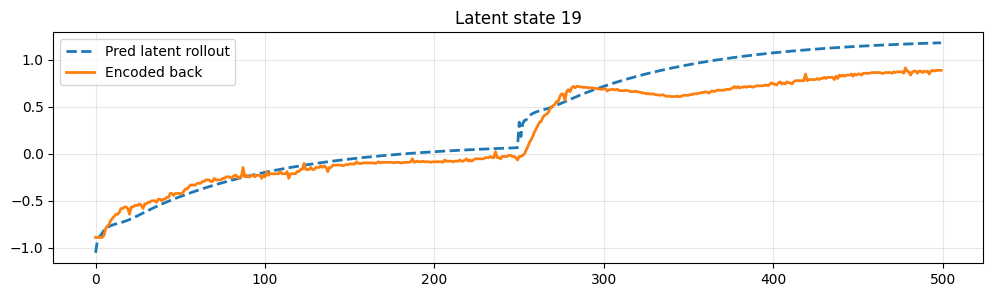

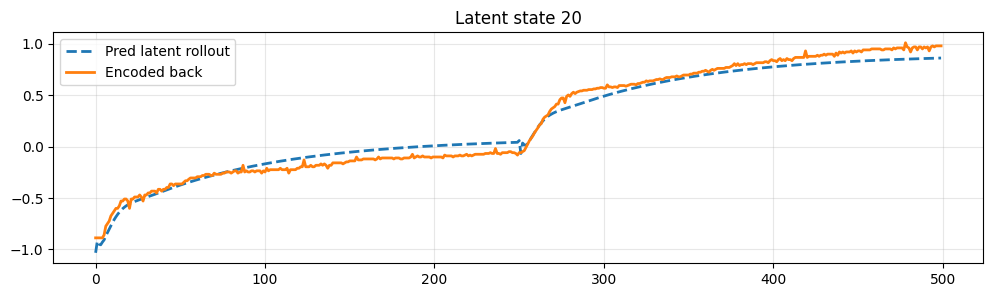

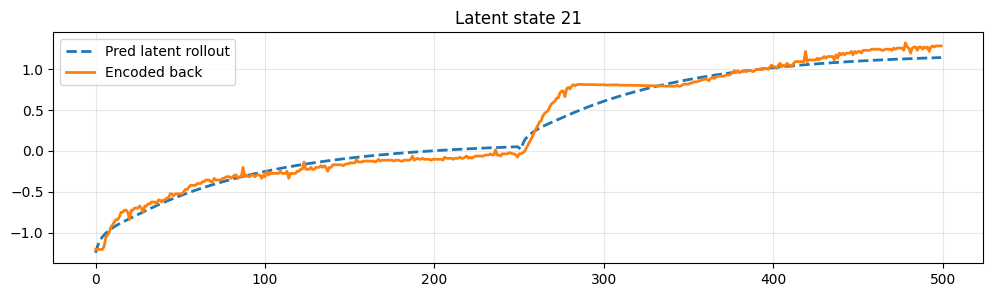

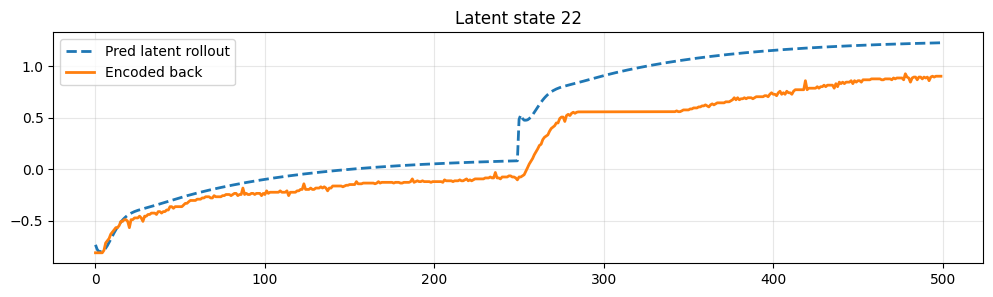

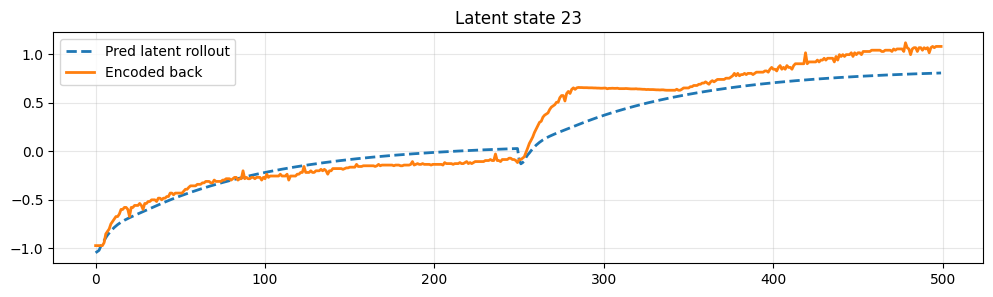

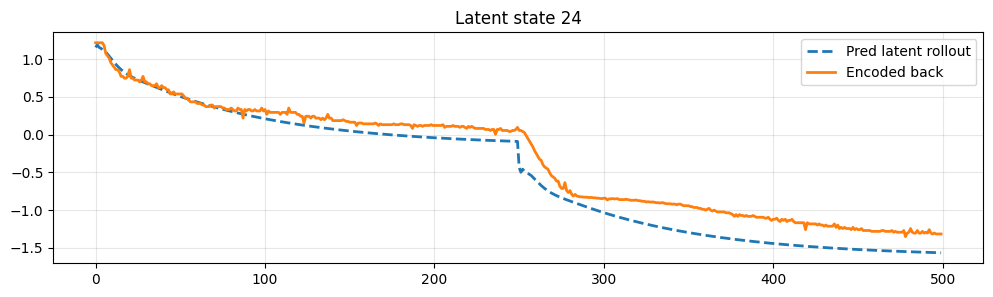

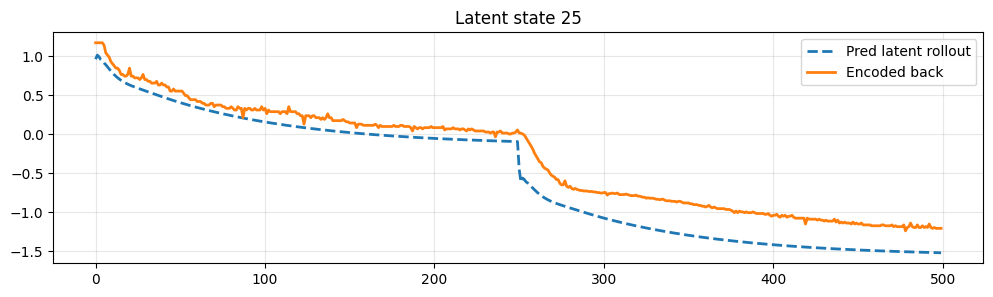

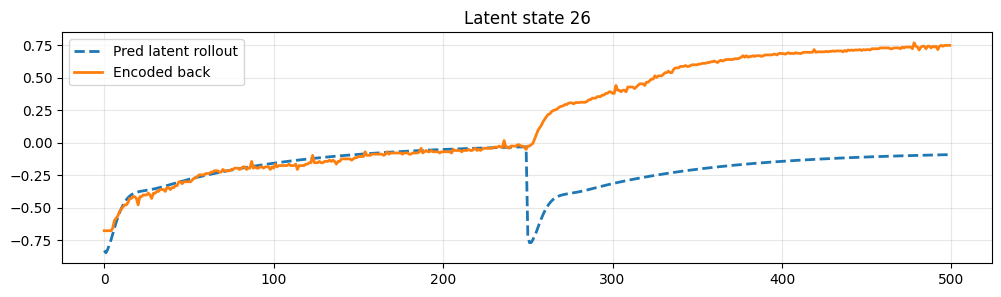

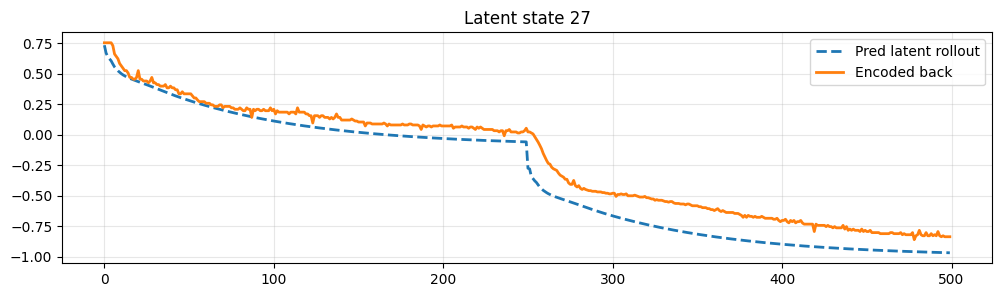

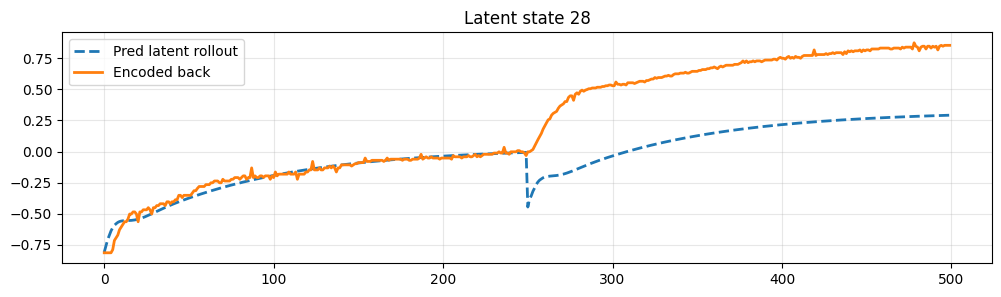

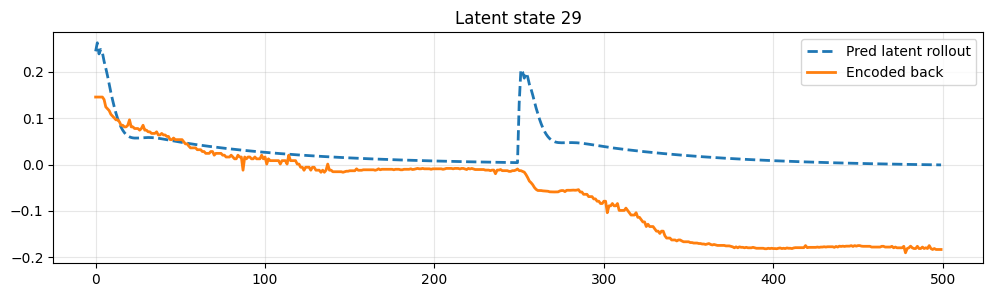

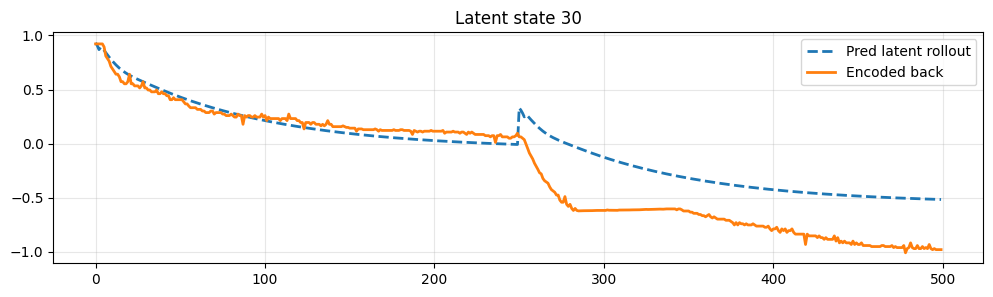

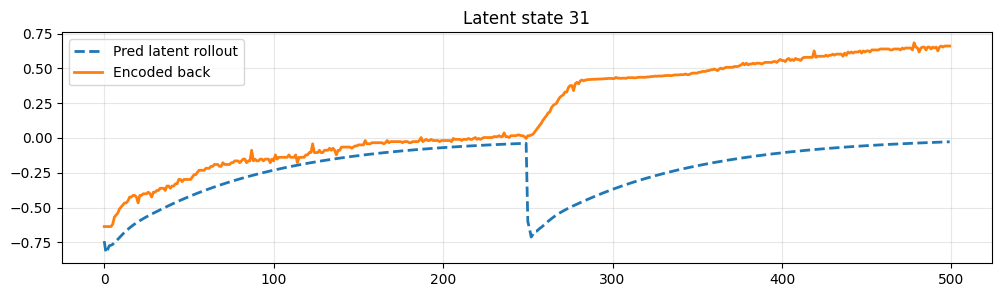

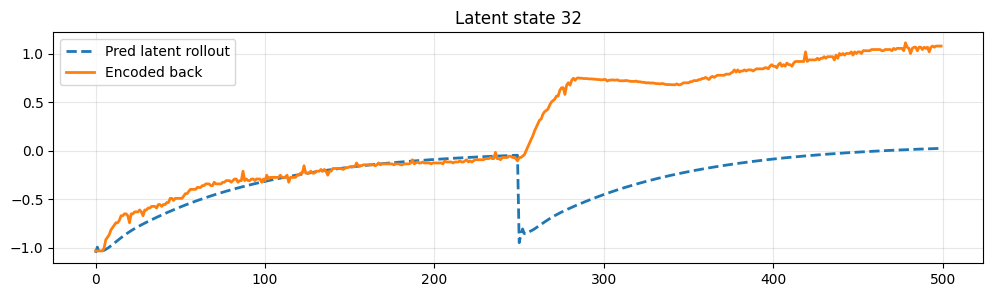

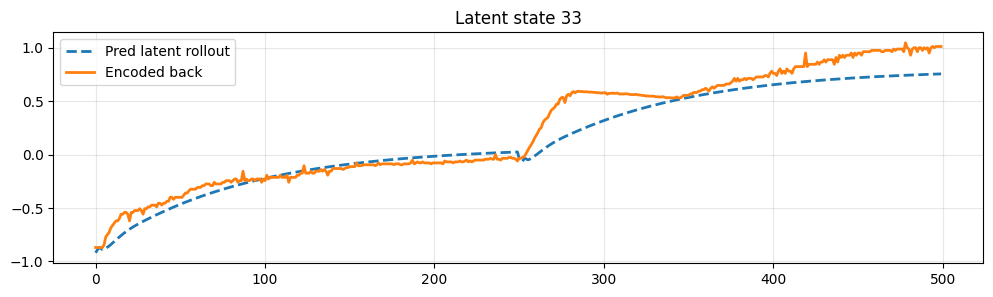

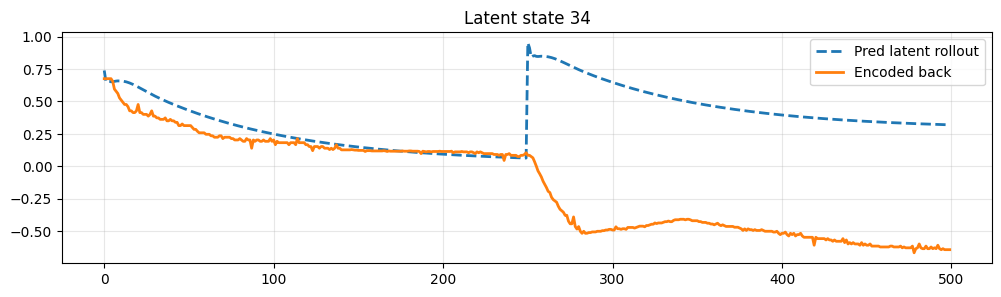

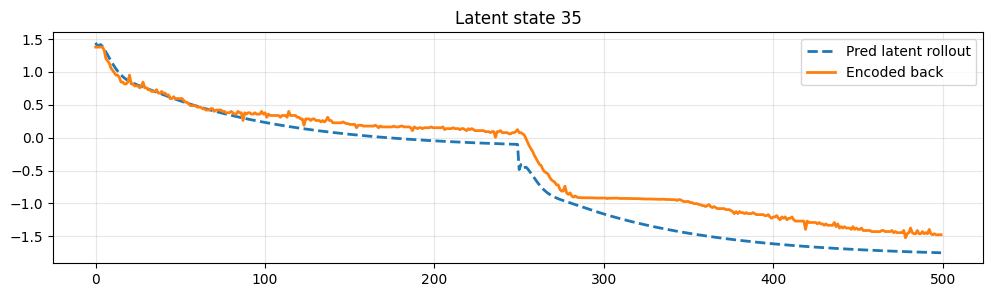

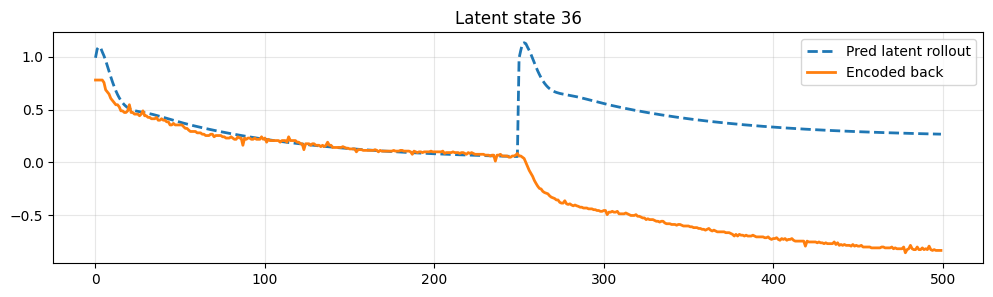

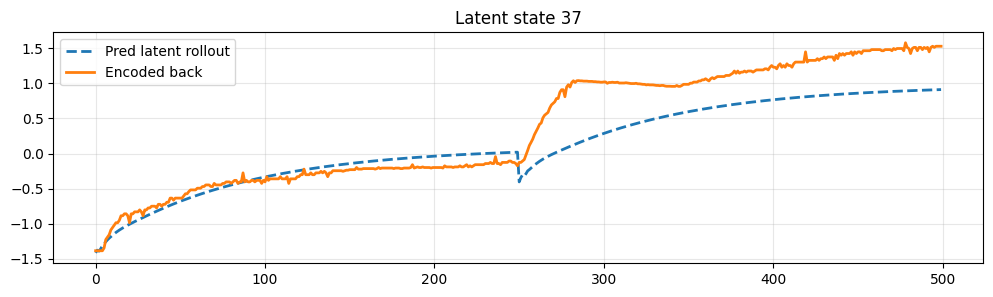

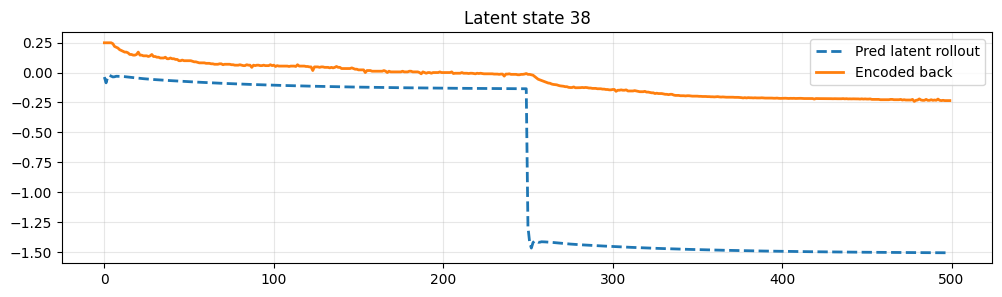

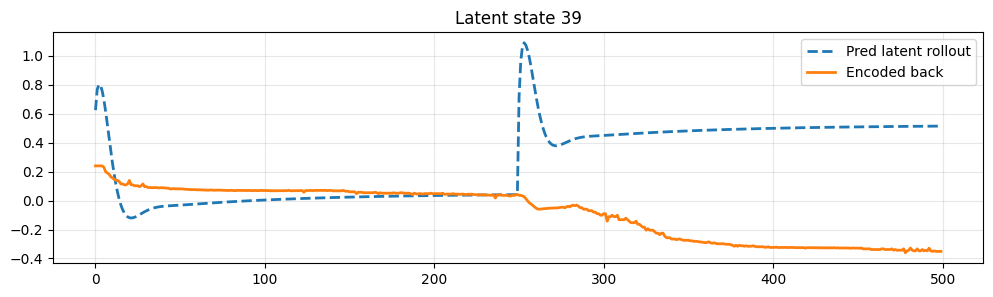

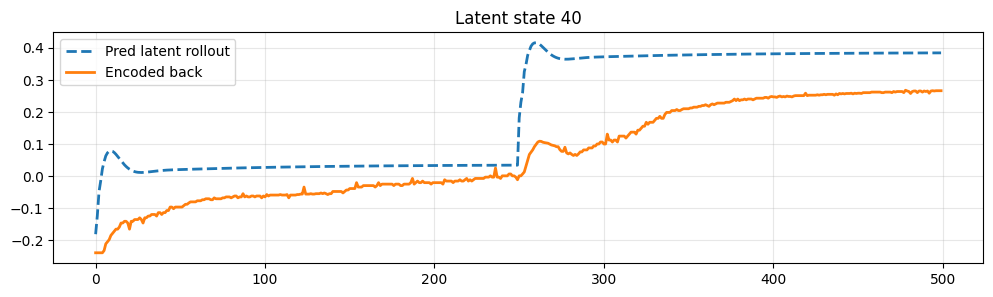

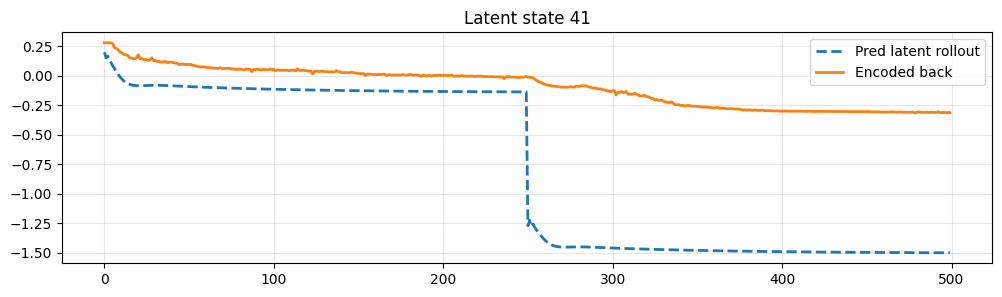

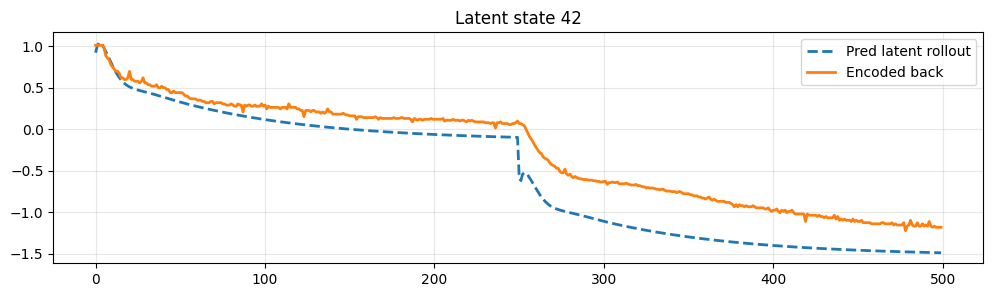

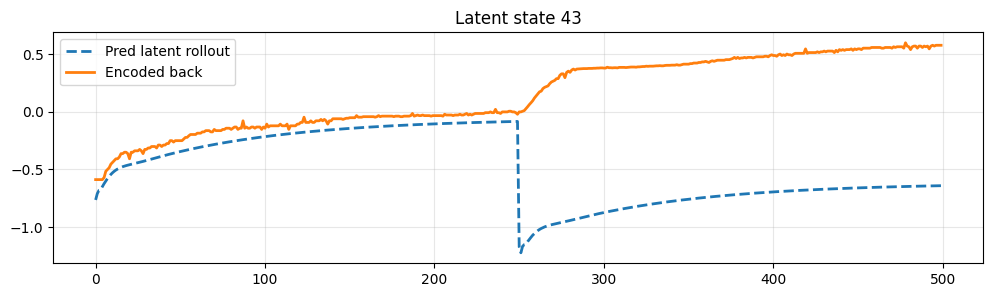

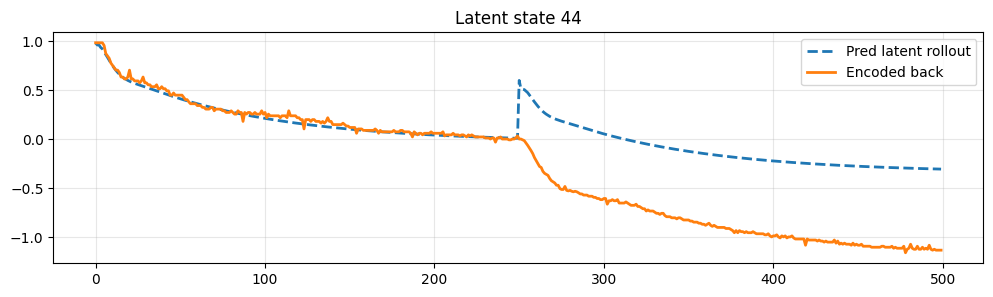

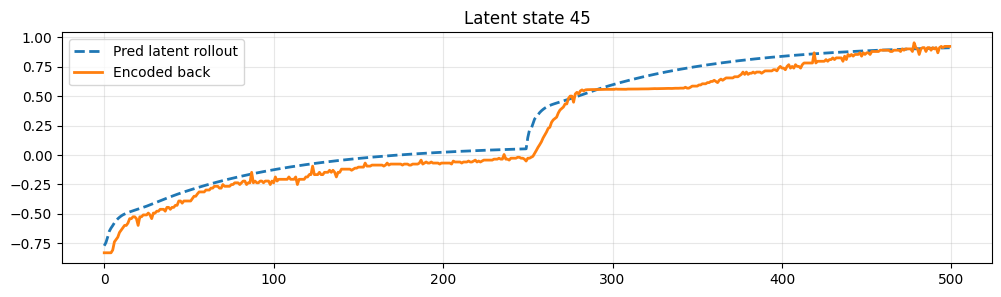

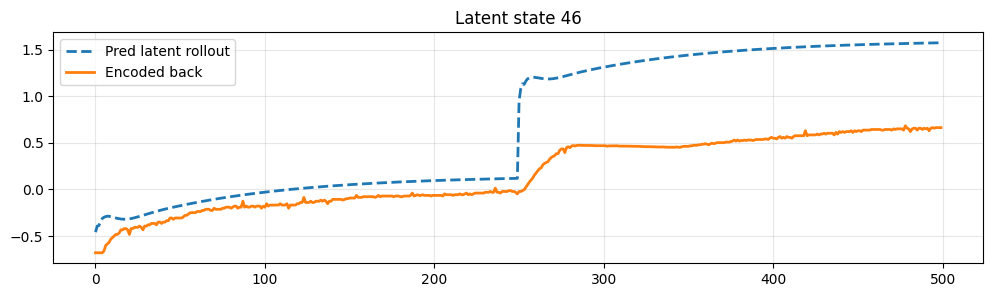

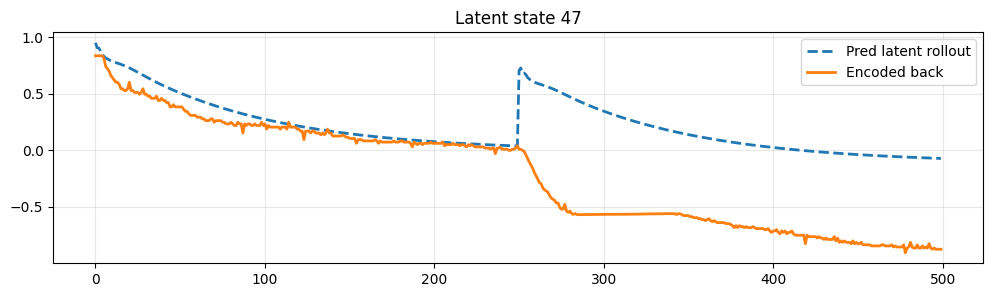

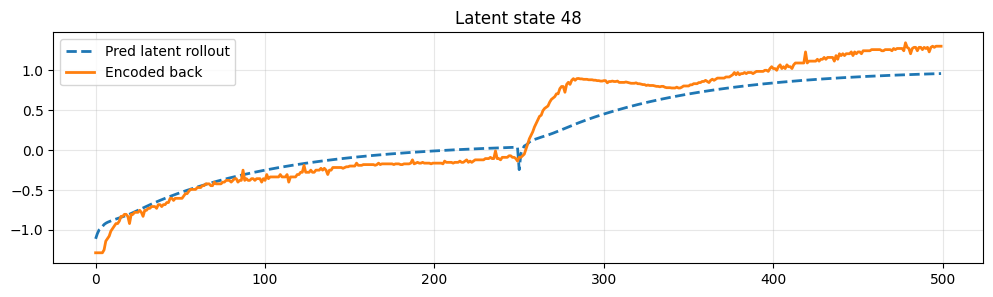

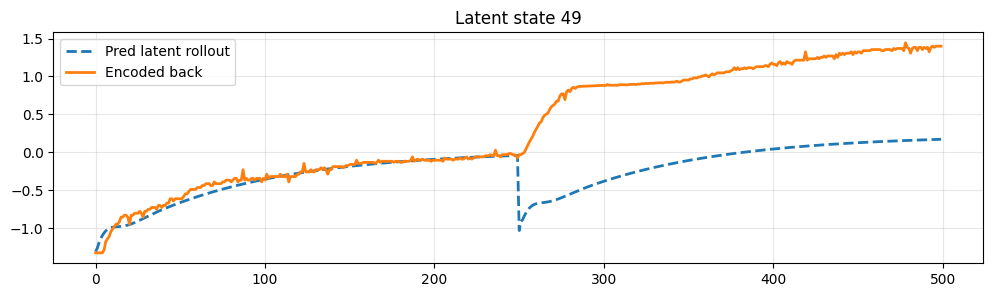

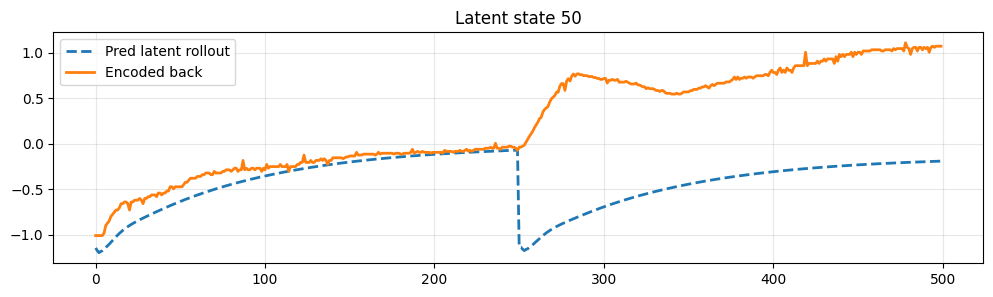

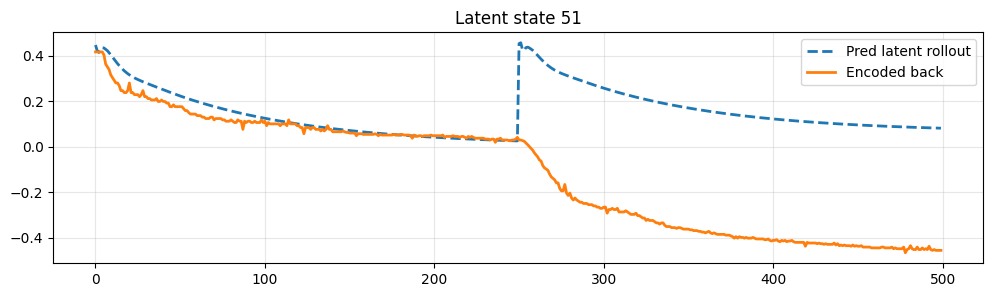

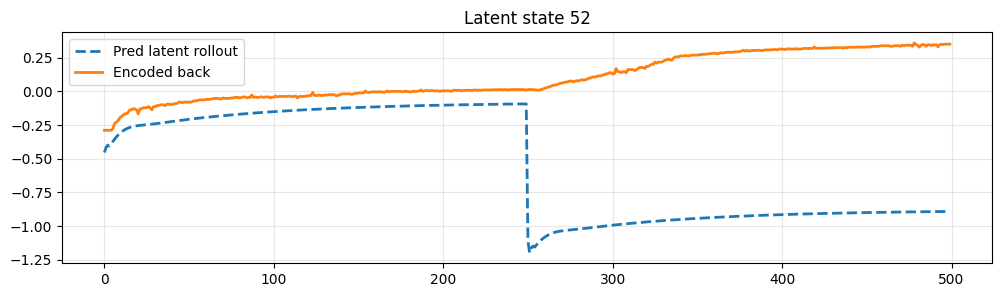

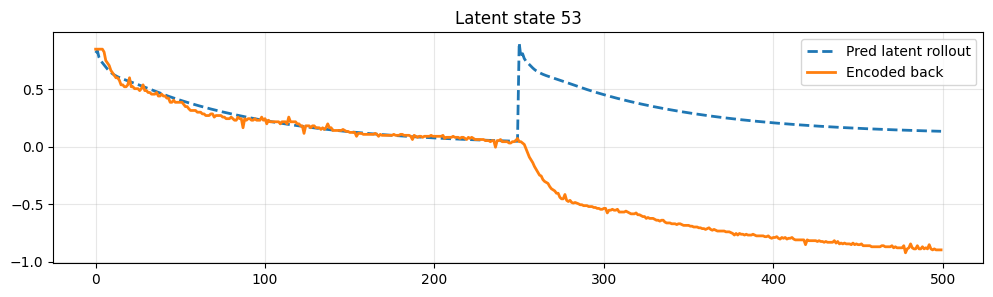

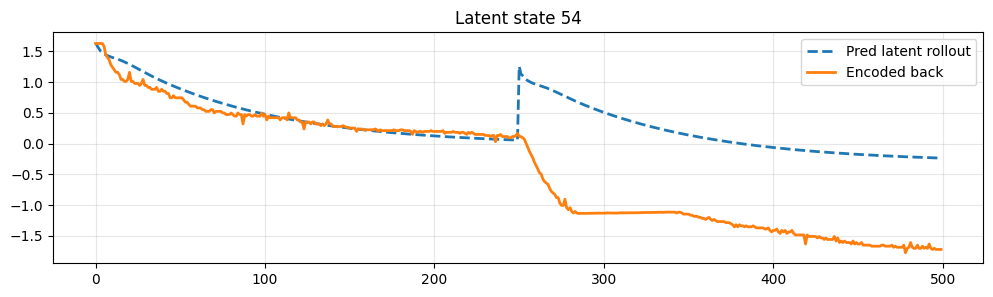

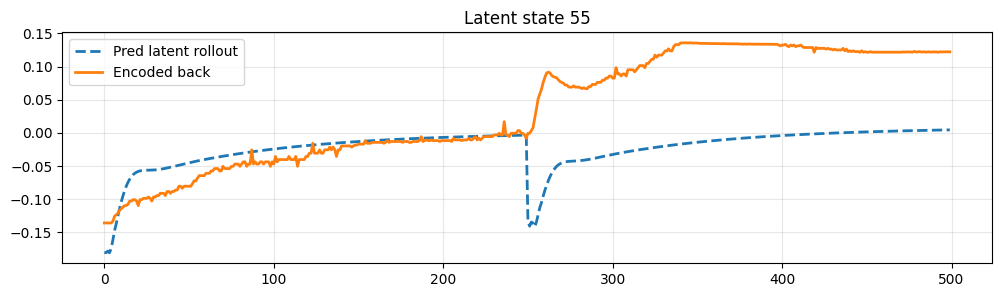

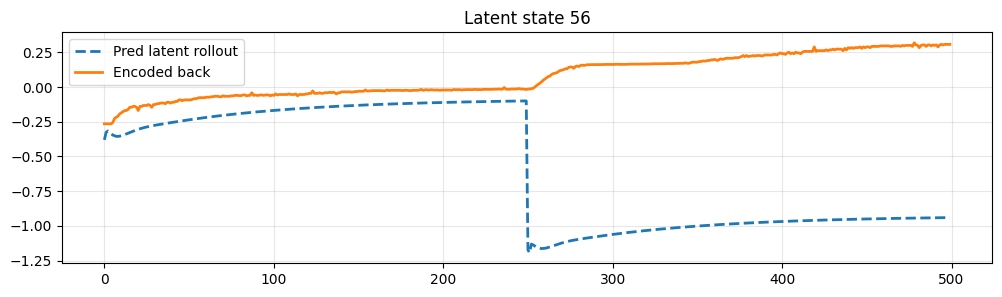

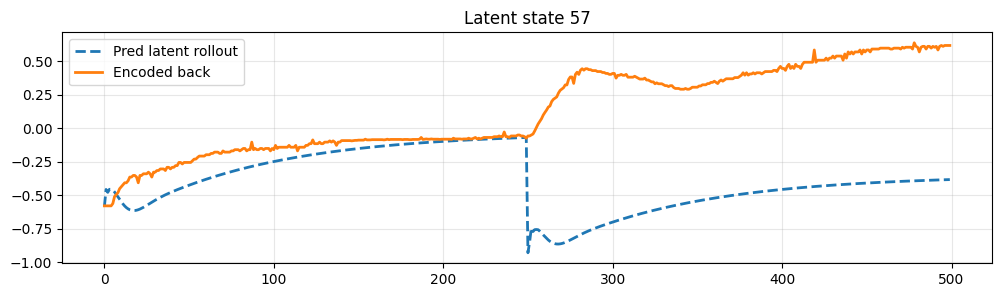

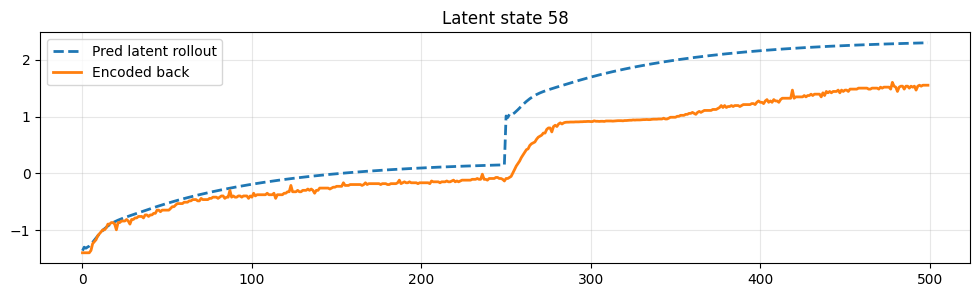

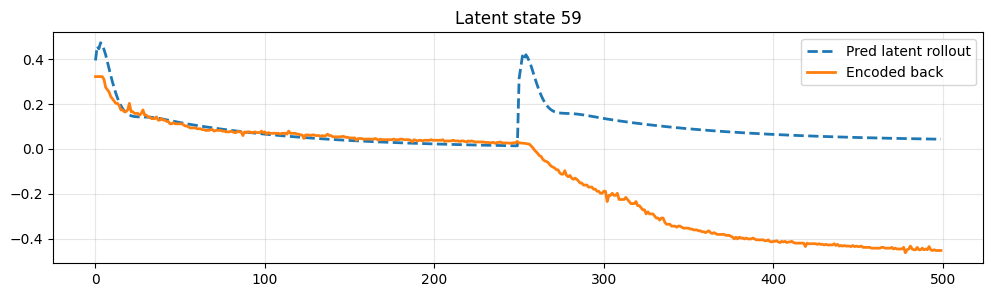

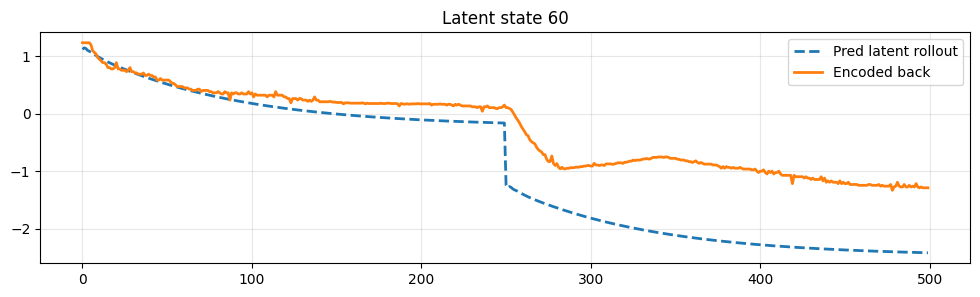

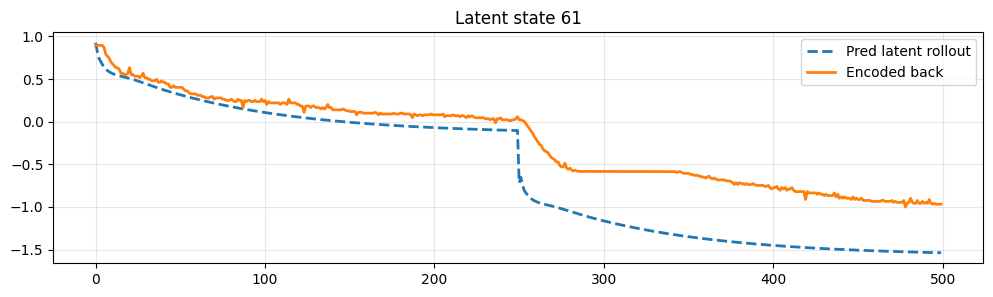

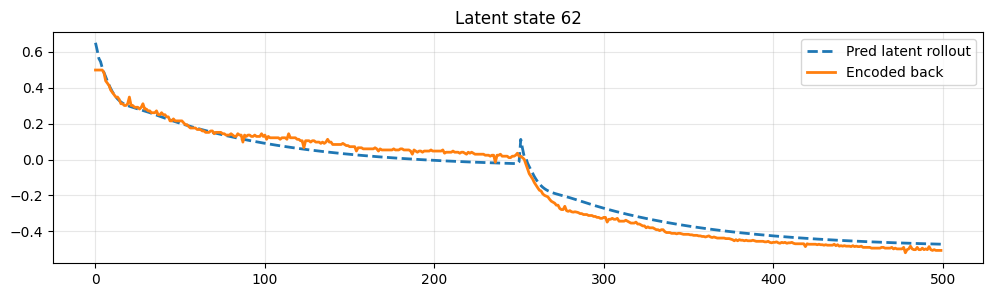

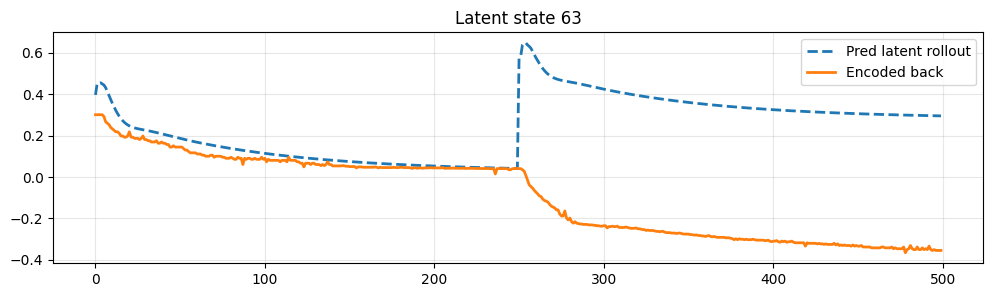

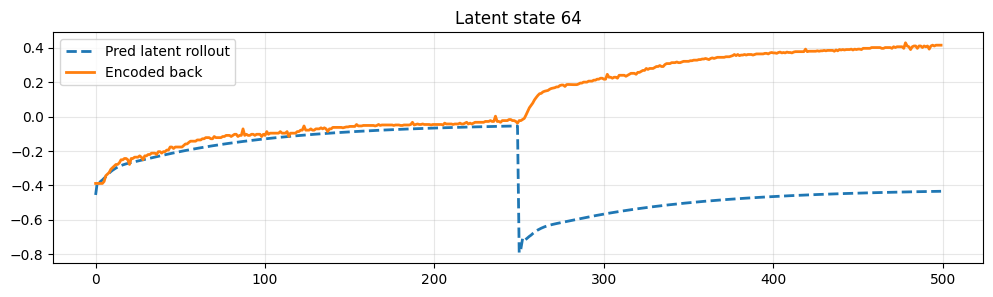

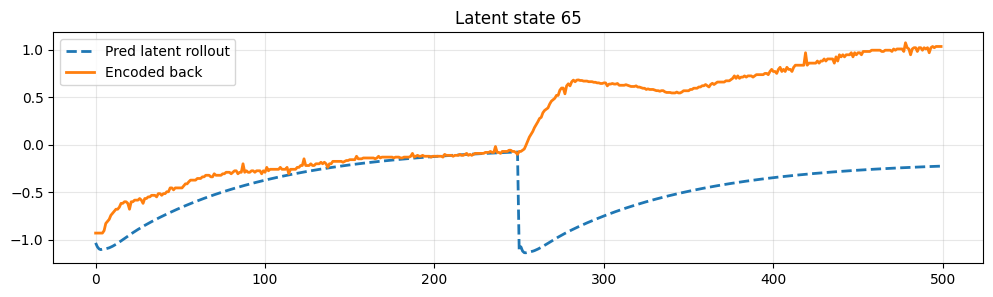

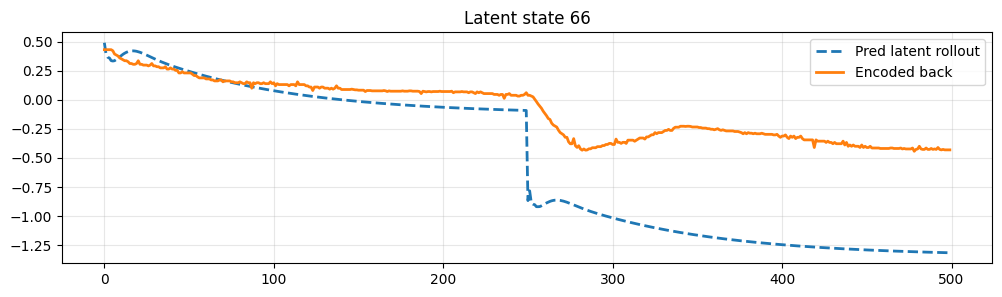

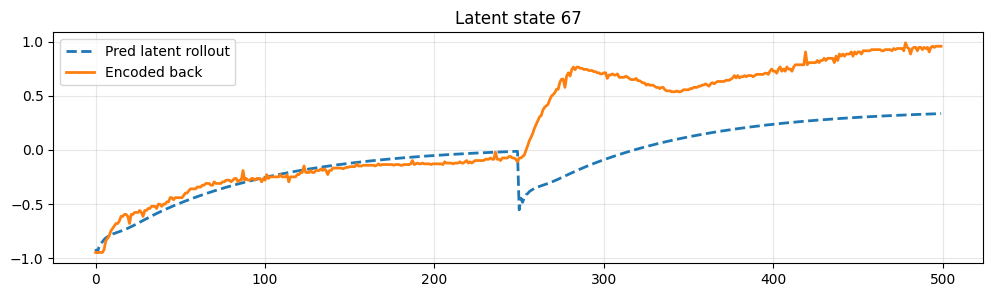

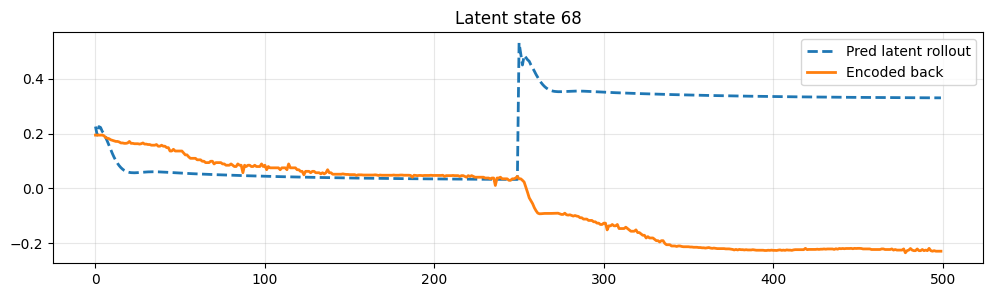

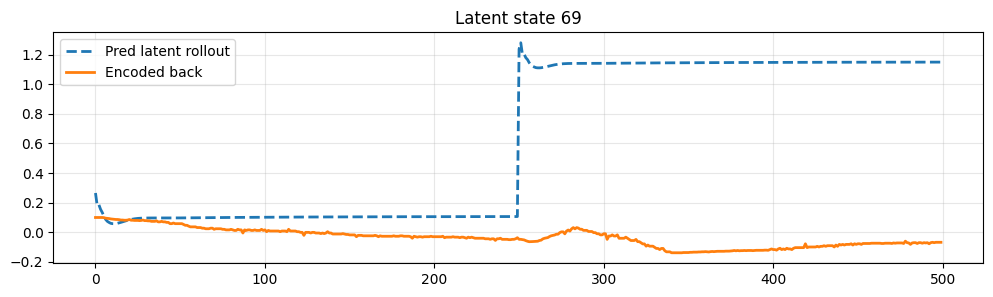

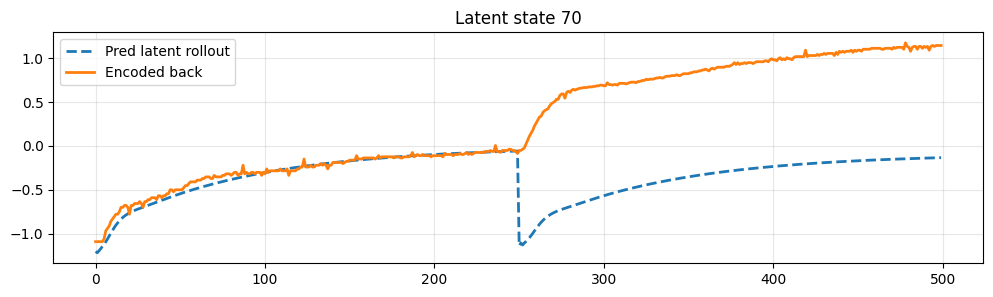

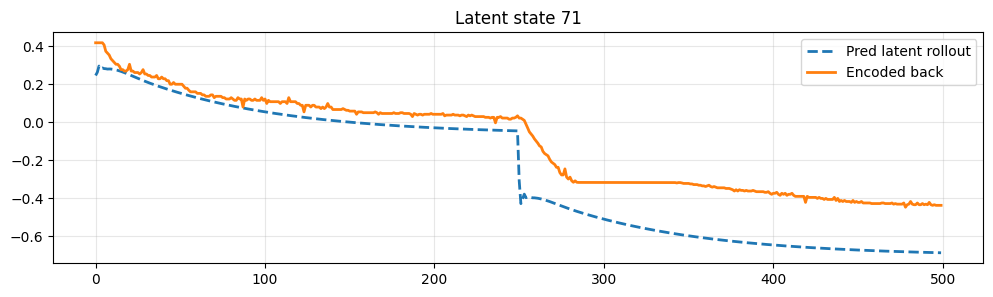

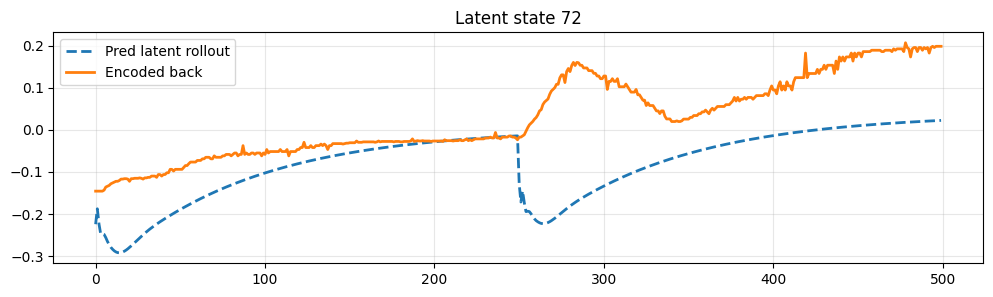

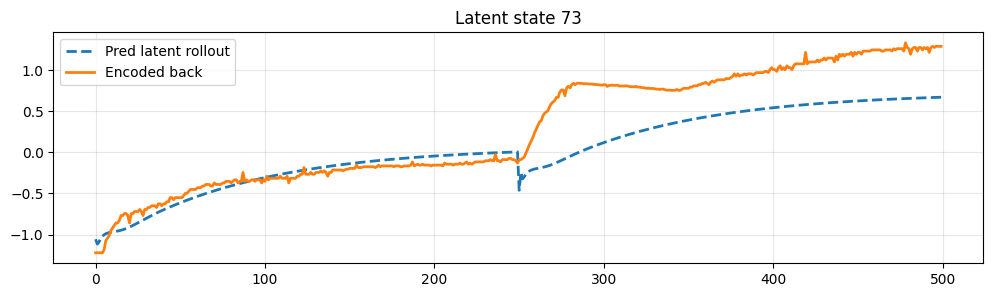

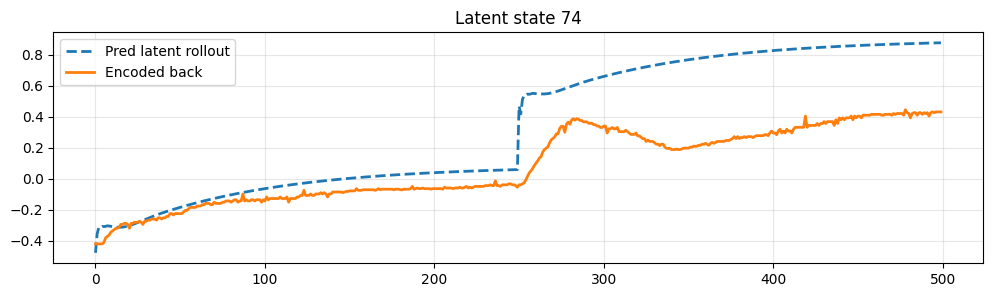

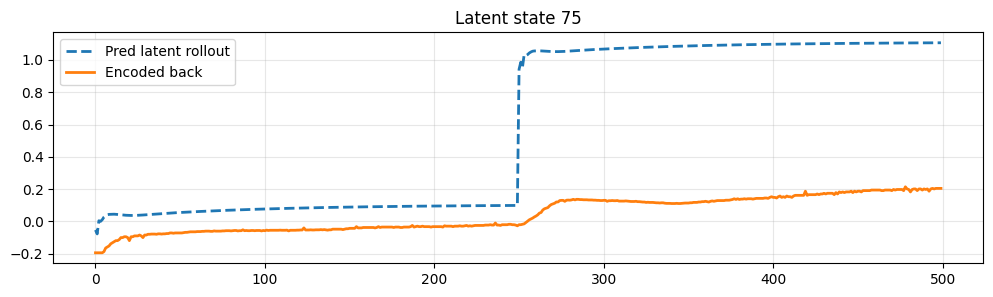

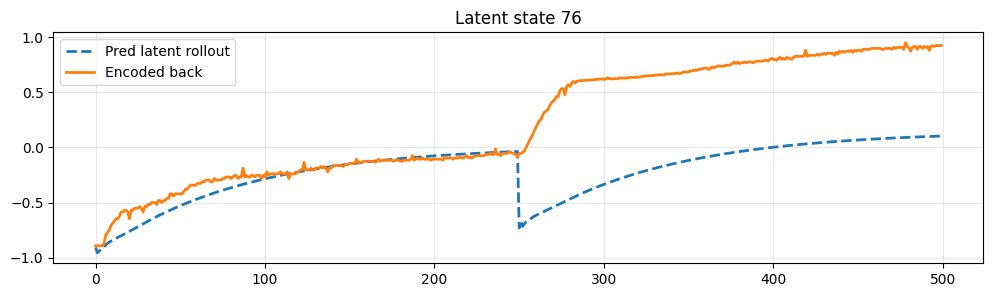

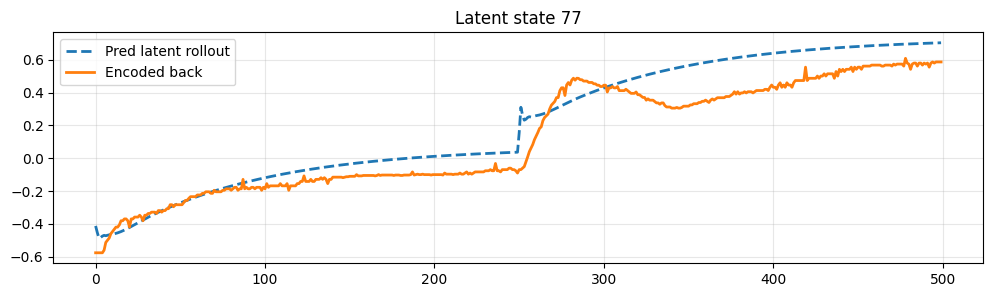

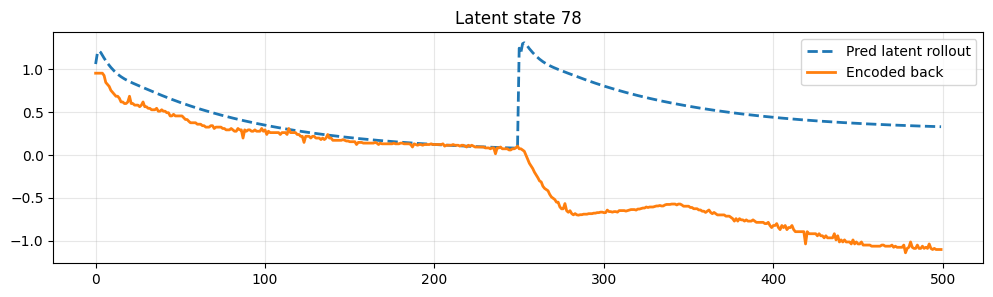

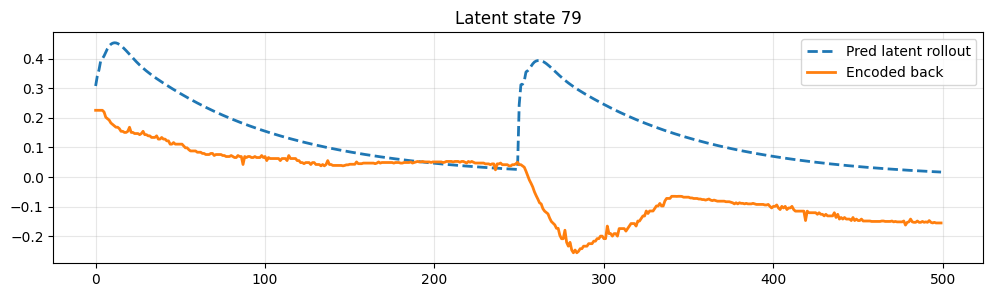

Average latent MSE: 0.32294969242211663


In [57]:
x_enc = problem.nodes[0]({"Y0": test_data["Y"][:, 1:pred_traj.shape[1] + 1, :]})
part = min(500, pred_x.shape[1])

error = 0.0
for i in range(nx_koopman):
    plt.figure(figsize=(12, 3))
    plt.plot(pred_x[i, :part], "--", linewidth=2, label="Pred latent rollout")
    plt.plot(x_enc["x"][0].detach().cpu().numpy()[:, i][:part], linewidth=2, label="Encoded back")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f"Latent state {i}")
    plt.show()

    error += np.mean(
        (pred_x[i, :part] - x_enc["x"][0].detach().cpu().numpy()[:, i][:part]) ** 2
    )

print("Average latent MSE:", error / nx_koopman)

Eigenfunction vizualizácia

C:\Users\ivadu\AppData\Local\Temp\ipykernel_31928\3231131266.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


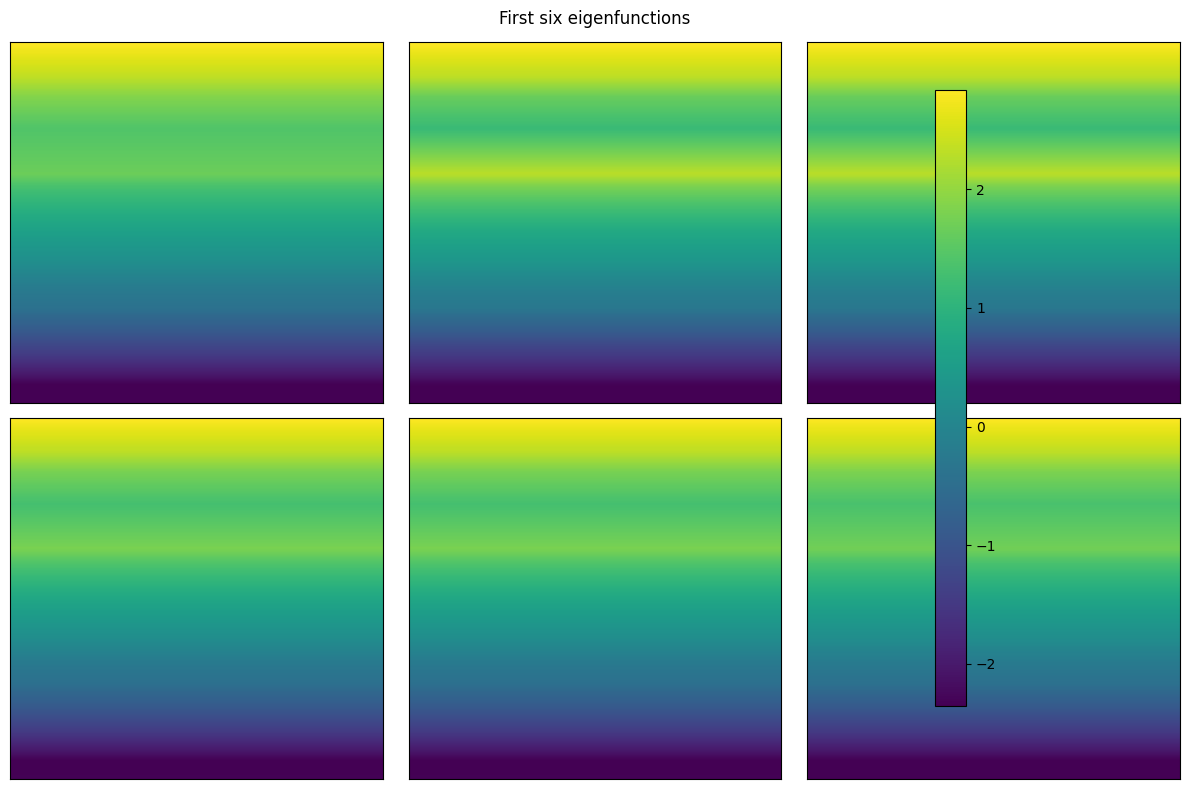

In [58]:
y_min = float(1.1 * test_data["Y"].min())
y_max = float(1.1 * test_data["Y"].max())

y1 = torch.linspace(y_min, y_max, 300)
y2 = torch.linspace(y_min, y_max, 300)
yy1, yy2 = torch.meshgrid(y1, y2, indexing="ij")

features = yy1.reshape(-1, 1)
latent = f_y(features)
latent = latent.view(300, 300, -1)

phi = torch.matmul(latent, torch.abs(eig_vec))

phi_1 = phi.detach().cpu().numpy()[:, :, 0]
phi_2 = phi.detach().cpu().numpy()[:, :, 1]
phi_3 = phi.detach().cpu().numpy()[:, :, 2]
phi_4 = phi.detach().cpu().numpy()[:, :, 3]
phi_5 = phi.detach().cpu().numpy()[:, :, 4]
phi_6 = phi.detach().cpu().numpy()[:, :, 5]

fig2, axs = plt.subplots(2, 3, figsize=(12, 8))
ims = []
ims.append(axs[0, 0].imshow(phi_1, aspect="auto"))
ims.append(axs[0, 1].imshow(phi_2, aspect="auto"))
ims.append(axs[0, 2].imshow(phi_3, aspect="auto"))
ims.append(axs[1, 0].imshow(phi_4, aspect="auto"))
ims.append(axs[1, 1].imshow(phi_5, aspect="auto"))
ims.append(axs[1, 2].imshow(phi_6, aspect="auto"))

for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig2.colorbar(ims[0], ax=axs)
fig2.suptitle("First six eigenfunctions")
plt.tight_layout()
plt.show()

MPC helper funkcia

In [59]:
u_ss_phys = 63.1
u_ss_scaled = (u_ss_phys - u_mean) / u_std

I = np.eye(A_koop.shape[0])
x_ss = np.linalg.solve(I - A_koop, B_koop * u_ss_scaled)
y_ss = get_y_phys(x_ss)

print("u_ss_phys =", u_ss_phys)
print("y_ss_phys =", y_ss)

u_ss_phys = 63.1
y_ss_phys = [[60.221397]]


In [69]:
dx = x - x_ss
du = u - u_ss_phys

In [71]:
du

array([ -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,
        -3.0999985,  -3.0999985,  -3.0999985,  -3.0999985,  -3.0

In [74]:
is_ctrl, rank_ctrl, Ctrb = controllability_test(A_koop, B_koop)
print("controllability rank =", rank_ctrl)
print("Ctrb norm =", np.linalg.norm(Ctrb))

controllability rank = 18
Ctrb norm = 5.1727204


In [75]:
x0 = get_x_phys(60.0)

u1 = (20.0 - u_mean) / u_std
u2 = (80.0 - u_mean) / u_std

x1 = A_koop @ x0 + B_koop * u1
x2 = A_koop @ x0 + B_koop * u2

y1 = get_y_phys(x1)
y2 = get_y_phys(x2)

print("y_next for u=20%:", y1)
print("y_next for u=80%:", y2)

y_next for u=20%: [[59.618088]]
y_next for u=80%: [[60.03972]]


In [76]:
def mpc_control_latent(A, B, x0, x_ref, N=30, Qx=None, Qu=1.0, Qdu=0.5,
                       umin=None, umax=None, u_prev=0.0):
    """
    MPC directly in latent space:
        x_{k+1} = A x_k + B u_k

    cost:
        sum (x_k - x_ref)^T Qx (x_k - x_ref) + Qu*u_k^2 + Qdu*(du_k)^2
    """
    nx_local = A.shape[0]

    if Qx is None:
        Qx = np.eye(nx_local)

    U = cp.Variable((1, N))
    X = cp.Variable((nx_local, N + 1))

    constr = [X[:, [0]] == x0.reshape(-1, 1)]
    obj = 0

    x_ref = x_ref.reshape(-1, 1)

    for k in range(N):
        constr += [X[:, [k + 1]] == A @ X[:, [k]] + B @ U[:, [k]]]

        x_err = X[:, [k]] - x_ref
        obj += cp.quad_form(x_err, Qx)
        obj += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            obj += Qdu * cp.sum_squares(U[:, [k]] - u_prev)
        else:
            obj += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k - 1]])

        if umin is not None:
            constr += [U[:, [k]] >= umin]
        if umax is not None:
            constr += [U[:, [k]] <= umax]

    prob = cp.Problem(cp.Minimize(obj), constr)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev)

    return float(U.value[0, 0])

Linearizácia decodera pre MPC output map

In [61]:
def decoder_jacobian(decoder, x0_col):
    x = torch.tensor(x0_col.reshape(1, -1), dtype=torch.float32, requires_grad=True)
    y = decoder(x)
    y.backward(torch.ones_like(y))
    J = x.grad.detach().cpu().numpy().copy()
    return J


x_ss_ctrl = get_x_scaled(np.array([[0.0]]))   # scaled steady-state approx
C_koop = decoder_jacobian(f_y_inv, x_ss_ctrl)

print("A_koop:", A_koop.shape)
print("B_koop:", B_koop.shape)
print("C_koop:", C_koop.shape)
print("x_ss_ctrl:", x_ss_ctrl.shape)

A_koop: (80, 80)
B_koop: (80, 1)
C_koop: (1, 80)
x_ss_ctrl: (80, 1)


Scaling a constraints pre MPC

In [62]:
x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("x_mean =", x_mean)
print("x_std  =", x_std)
print("u_mean =", u_mean)
print("u_std  =", u_std)

umin = (20.0 - u_mean) / u_std
umax = (100.0 - u_mean) / u_std
ymin = (0.0 - x_mean) / x_std
ymax = (70.0 - x_mean) / x_std

x_mean = 58.337700739046234
x_std  = 7.119317273516296
u_mean = 63.08828052906798
u_std  = 23.987293259622874


Closed-loop MPC na current Koopman modeli

In [ ]:
Qx = np.eye(nx_koopman)
Qu = 0.1
Qdu = 1.0
N = 40
sim_length = 150
T0 = 60.0

x_hist = np.zeros((nx_koopman, sim_length + 1))
u_hist = np.zeros((nu, sim_length))
y_hist_scaled = np.zeros((ny, sim_length))
y_hist_phys = np.zeros((ny, sim_length))

x_hist[:, [0]] = get_x_phys(T0)
x_ref = get_x_phys(x_mean)   # steady-state reference
u_prev = 0.0

for t in range(sim_length):
    uk_scaled = mpc_control_latent(
        A_koop, B_koop,
        x_hist[:, [t]],
        x_ref,
        N=N,
        Qx=Qx,
        Qu=Qu,
        Qdu=Qdu,
        umin=umin,
        umax=umax,
        u_prev=u_prev
    )

    u_hist[:, t] = uk_scaled

    # plant = current Koopman model
    x_hist[:, [t+1]] = A_koop @ x_hist[:, [t]] + B_koop * uk_scaled

    yk_scaled = get_y_scaled(x_hist[:, [t+1]])
    y_hist_scaled[:, [t]] = yk_scaled
    y_hist_phys[:, [t]] = scaler.inverse_transform(yk_scaled.T).T

    u_prev = uk_scaled

print("Closed-loop simulation finished.")

Closed-loop simulation finished.


Plot MPC výsledkov

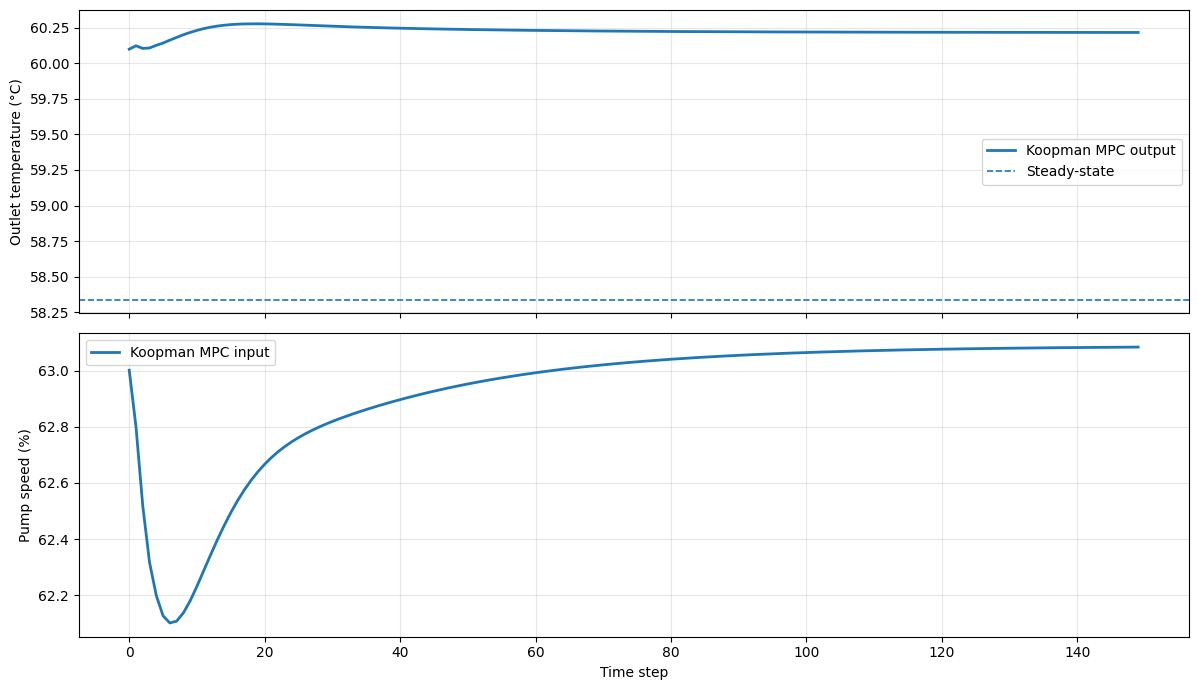

In [64]:
u_hist_phys = scalerU.inverse_transform(u_hist.T).T

tY = np.arange(sim_length)
tU = np.arange(sim_length)

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(tY, y_hist_phys[0], linewidth=2, label="Koopman MPC output")
ax[0].axhline(x_mean, linestyle="--", linewidth=1.2, label="Steady-state")
ax[0].set_ylabel("Outlet temperature (°C)")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(tU, u_hist_phys[0], linewidth=2, label="Koopman MPC input")
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Pump speed (%)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [65]:
summary = {
    "mse_scaled": mse_scaled,
    "mse_physical": mse_phys,
    "controllable": is_controllable,
    "controllability_rank": rank,
    "train_time_sec": end - start,
}

summary_df = pd.DataFrame([summary])
print(summary_df)

NameError: name 'mse_phys' is not defined